# SolidGen content characterization
This file analyzes data extracted from `https://git.autodesk.com/lambouj/proc_step/blob/master/proc_step/solidgen_with_spline_stats.py` to produce statistics on the number of B-Rep models which can be consumed by SolidGen with additional spline support.

As always, content characterization is a "map-reduce" workflow.   The script `solidgen_with_spline_stats.py` maps B-Rep bodies to json data.   This notebook is the "reduce" step, which aggregates stats from all the json files.

In [1]:
import json
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter, defaultdict
from tqdm import tqdm
from IPython.display import display, Markdown
from PIL import Image, ImageDraw, ImageFont
from IPython.display import display, Markdown, display_markdown # to display images
import random
import math

In [2]:
# Path to the json files extracted by https://git.autodesk.com/lambouj/proc_step/blob/master/proc_step/solidgen_with_spline_stats.py
data_path = Path("/media/data/ABC/solidgen_spline2/stats/")
image_path = Path("/media/data/ABC/cloud_processed/0.0.0/text_image_dataset")

In [3]:
def filter_array(a, max_value=None):
    if max_value == None:
        print("No max value")
        return a
    filtered = []
    for d in a:
        if d <= max_value:
            filtered.append(d)
    return np.array(filtered).flatten()
        
    
def flatten_dict(d):
    flat_list = []
    for key in d:
        flat_list.extend(d[key])
    return flat_list

def add_hist_to_axis(ax, label, bin_edges, data, max_value=None):
    data = filter_array(data, max_value)
    counts, _ = np.histogram(data, bins=bin_edges)
    num_bins = len(bin_edges) - 1
    width = 0.8*(bin_edges.max() - bin_edges.min()) / num_bins
    ax.bar(bin_edges[0:-1], counts, width=width, label=label)
    
def plot_historgram(title, data, num_bins = 20, max_value=None, ymax=None, xlabel=None, ylabel=None):
    if isinstance(data, dict):
        hdata = np.array(flatten_dict(data))
    else:
         hdata = np.array(data).flatten()

    print(f"Max value {hdata.max()}.   Min value {hdata.min()}")
    print(f"Truncating graph at {max_value}")
    
    counts, bin_edges = np.histogram(filter_array(hdata, max_value), bins=num_bins)
    
    fig = plt.figure()
    ax = fig.add_axes([0,0,1,1])
    
    if isinstance(data, dict):
        for key in data:  
            add_hist_to_axis(ax, key, bin_edges, data[key], max_value)
        ax.legend()
    else:
        add_hist_to_axis(ax, None, bin_edges, hdata, max_value)
        
    plt.title(title)
    if xlabel is not None:
        ax.set_xlabel(xlabel)
    if ylabel is not None:
        ax.set_ylabel(ylabel)
    if ymax is not None:
        ax.set_ylim([0, ymax])
    plt.show()

def plot_bar_chart_for_counts(title, data, ylabel=None, rotation=False):
    c = Counter(data)
    num_bars = min(len(c), 20)
    common = c.most_common(num_bars)
    names = []
    values = []
    for item in common:
        names.append(item[0])
        values.append(item[1])
    fig = plt.figure()
    ax = fig.add_axes([0,0,1,1])
    ax.bar(names,values)
    if rotation:
        plt.xticks(rotation=90)
    if ylabel is not None:
        ax.set_ylabel(ylabel)
    plt.title(title)
    plt.show()

def plot_pie_chart(title, labels, sizes):
    fig, ax = plt.subplots()
    ax.pie(sizes, labels=labels)
    plt.title(title)
    plt.show()

def update_counter_data(c, d):
    c.update(d)
    
def is_prismatic_only(data):
    return len(data["surface_types"]["non_prismatic_faces"]) == 0 and \
           len(data["curve_types"]["non_prismatic_curves"]) == 0

def find_tols_in_bits(data):
    bb_max_length = data["bounding_box"]["max_bounding_box_length"]
    bits_values = [ 5, 6, 7, 8]
    tols = {}
    for b in bits_values:
        value = 2 ** b
        tol = bb_max_length/value
        tols[b] = tol
    
    last_tol = None
    for b in bits_values:
        tol = tols[b]
        if last_tol is not None:
            if tol >= last_tol:
                print(tols)
            assert tol < last_tol, "Tol should be smaller"
        last_tol = tol
        
    
    return tols

In [4]:
def find_best_fit(fit_analysis):
    tiny_edge_tol = 1e-3 # mm   If we approximate the edges as well as this then all good
    best_fit = None
    for f in fit_analysis:
        if "error" in f:
            continue
        else:
            best_fit = f
            break
    if best_fit is None:
        return fit_analysis[0]
    for f in fit_analysis:
        if "error" in f:
            continue
        if f["max_edge_deviation"] < tiny_edge_tol:
            # If the edge approximation tolerance is small then 
            # the best fit is the best hausdorff_distance from the face 
            # to the approximation surface
            if not "hausdorff_distance" in f:
                print(f)
            if f["hausdorff_distance"] < best_fit["hausdorff_distance"]:
                best_fit = f
        else:
            # Otherwise we always look for a better max_edge_deviation as this defines watertightness
            if f["max_edge_deviation"] < best_fit["max_edge_deviation"]:
                best_fit = f
    return best_fit

def find_face_bin(num_faces):
    if num_faces <= 6:
        return "Very small (num_faces <= 6)"
    if num_faces <= 30:
        return "Small (6 < num_faces <= 30)"
    if num_faces <= 100:
        return "Medium (30 < num_faces <= 100)"
    if num_faces <= 300:
        return "Large (100 < num_faces <= 300)"
    return "XL (300 < num_faces)"

In [5]:
def image_grid(imgs, rows, cols, resize=False, texts=None):
        
    if resize:
        scale = 1/3
        w, h = imgs[0].size
        newsize = (int(w*scale), int(h*scale))
        imgs = [ img.resize(newsize) for img in imgs]

    w, h = imgs[0].size

    grid_w = cols*w
    grid_h = rows*h
    grid = Image.new('RGB', size=(grid_w, grid_h), color="white")

    
    I1 = ImageDraw.Draw(grid)
    
    for i, img in enumerate(imgs):
        x = i%cols*w
        y = i//cols*h
        grid.paste(img, box=(x, y))
        if texts is not None:
            assert len(texts) ==  len(imgs), "Should have text for each image"
            text = texts[i]
            I1.text((x, y), text, fill=(0, 0, 0))
    return grid

def create_image_grid_for_examples(file_stems, image_path):
    png_paths = []
    json_paths = []
    num_images_per_row = 5
    k = num_images_per_row*num_images_per_row
    for s in file_stems:
        chunk = s[0:4]
        chunk_path = image_path / chunk
        png_path = chunk_path / (s + ".png")
        if png_path.exists():
            png_paths.append(png_path)
            json_path =  chunk_path / (s.rpartition("_")[0] + ".json")
            assert json_path.exists(), "Json files doesn't exist"
            json_paths.append(json_path)

            
    total_num_images = len(png_paths)
    if total_num_images == 0:
        print("No bodies found")
        return None
    
    if k > total_num_images:
        k = total_num_images
    chosen_indices = random.sample(range(total_num_images), k=k)
  
    imgs = []
    texts = []
    for i in chosen_indices:
        png_file = png_paths[i]
        json_file = json_paths[i]
        img = Image.open(png_file)
        imgs.append(img)
        
        with open(json_file, "r") as fp:
            data = json.load(fp)
        texts.append(data["solid_name"])
        
    num_images = len(imgs)
    sq_max = math.ceil(math.sqrt(num_images))
    grid = image_grid(imgs, sq_max, sq_max, resize=False, texts=texts)
    return grid

In [6]:
files = list(data_path.glob("*.json"))
print(f"Total number of B-Rep bodies {len(files)}")

Total number of B-Rep bodies 11088


In [7]:
entity_properties = [
    "num_faces",
    "num_edges",
    "num_vertices"
]
entity_hist_data = defaultdict(list)
prismatic_only_bodies = defaultdict(list)
approximatable_bodies_6bit = defaultdict(list)
arc_approx_for_tol = defaultdict(int)
cubic_spline_approx_for_tol = defaultdict(int)
quintic_spline_approx_for_tol = defaultdict(int)
no_edge_approx_for_tol = defaultdict(int)
no_surf_approx_for_tol = defaultdict(int)

bodies_approx_for_tol = defaultdict(int)
bodies_cant_approx_for_tol = defaultdict(int)
all_edges = 0
num_np_faces_all = 0
num_np_faces_fit_ok = 0
num_np_faces_out_of_tol = 0
all_non_prismatic_edges = 0
all_non_prismatic_edges_with_curves = 0
surface_types_counter = Counter()
curve_types_counter = Counter()
non_prismatic_surface_approximations_status = []
no_spline_edge_surface_types = []
best_fitting_patch_types = []
best_fitting_fit_type = []
edge_approx_for_tol = defaultdict(int)
surface_approx_for_tol = defaultdict(int)
prismatic_bodies_which_can_be_approximated = defaultdict(list)
non_prismatic_bodies_which_can_be_approximated = defaultdict(list)
non_prismatic_bodies_which_cant_be_approximated = defaultdict(list)
num_edges_on_non_prismatic_faces = []

In [8]:
for file in files:
    try:
        with open(file, "r") as fp:
            data = json.load(fp)
    except Exception as ex:
        print(f"Exception {ex}")
        continue
    for ent in entity_properties:
        entity_hist_data[ent].append(data[ent])
        if is_prismatic_only(data):
            prismatic_only_bodies[ent].append(data[ent])
    update_counter_data(surface_types_counter, data["surface_types"]["face_type_counts"])
    update_counter_data(curve_types_counter, data["curve_types"]["curve_type_counts"])
    
    face_bin = find_face_bin(data["num_faces"])
    if is_prismatic_only(data):
        prismatic_bodies_which_can_be_approximated[face_bin].append(file.stem)
        
    
    all_edges += data["num_edges"]
    all_non_prismatic_edges += len(data["curve_types"]["non_prismatic_curves"])
    
    tols = find_tols_in_bits(data)
    biggest_tol = tols[5]
    for curve_info in data["curve_types"]["non_prismatic_curves"]:
        if curve_info["status"] != "Can't get edge curve":
            all_non_prismatic_edges_with_curves += 1
            
    for surface_info in data["surface_types"]["non_prismatic_faces"]:
        num_np_faces_all += 1
        num_edges_on_non_prismatic_faces.append(surface_info["num_edges"])
        if "fit_analysis" in surface_info:
            best_fit = find_best_fit(surface_info["fit_analysis"])
            if "error" in best_fit:
                error = best_fit["error"]
                if len(error) > 8:
                    error = error[0:8]
                non_prismatic_surface_approximations_status.append(error)
            else:
                non_prismatic_surface_approximations_status.append("Fit success")
                best_fitting_patch_types.append(best_fit["patch_type"])
                best_fitting_fit_type.append(best_fit["fit_type"])
                num_np_faces_fit_ok += 1
                if best_fit["hausdorff_distance"] > biggest_tol:
                    num_np_faces_out_of_tol += 1
        elif "reason_for_not_fitting"  in surface_info:
            non_prismatic_surface_approximations_status.append(surface_info["reason_for_not_fitting"])
            if surface_info["reason_for_not_fitting"] == "No spline edges":
                no_spline_edge_surface_types.append(surface_info["original_face_type"])
        else:
            assert False, "No fit analysis and no reason"
                    
    
    try:
        for b in tols:
            tol = tols[b]
            can_approx_all = True
            for curve_info in data["curve_types"]["non_prismatic_curves"]:
                if curve_info["status"] != "Can't get edge curve":
                    if curve_info["approx_arc"]["max_error"] < tol:
                        arc_approx_for_tol[b] += 1
                    elif curve_info["approx_cubic"]["max_error"] < tol:
                        cubic_spline_approx_for_tol[b] += 1
                    elif curve_info["approx_quintic"]["max_error"] < tol:
                        quintic_spline_approx_for_tol[b] += 1
                    else:
                        no_edge_approx_for_tol[b] += 1
                        can_approx_all = False
                        
            for surface_info in data["surface_types"]["non_prismatic_faces"]:
                can_approx_face = False
                if "fit_analysis" in surface_info:
                    best_fit = find_best_fit(surface_info["fit_analysis"])
                    if not "error" in best_fit:
                        if best_fit["max_edge_deviation"] < tol:
                            edge_approx_for_tol[b] += 1
                        if best_fit["hausdorff_distance"] < tol:
                            surface_approx_for_tol[b] += 1
                            can_approx_face = True
                        

                if not can_approx_face:
                    no_surf_approx_for_tol[b] += 1
                    can_approx_all = False
                    
                
                
            if can_approx_all:
                bodies_approx_for_tol[b] += 1
                if b == 6:
                    for ent in entity_properties:
                        approximatable_bodies_6bit[ent].append(data[ent])
                    if not is_prismatic_only(data):
                        non_prismatic_bodies_which_can_be_approximated[face_bin].append(file.stem)
                
                        
            else:
                bodies_cant_approx_for_tol[b] += 1
                if b == 6:
                    non_prismatic_bodies_which_cant_be_approximated[face_bin].append(file.stem)
                

                
    except Exception as ex:
        print(f"Exception {ex}")

Exception Expecting ',' delimiter: line 1801 column 50 (char 81779)
Exception Expecting value: line 940 column 47 (char 48961)
Exception Expecting value: line 1 column 1 (char 0)


## Entity Counts

Max value 3505.   Min value 1
Truncating graph at 50


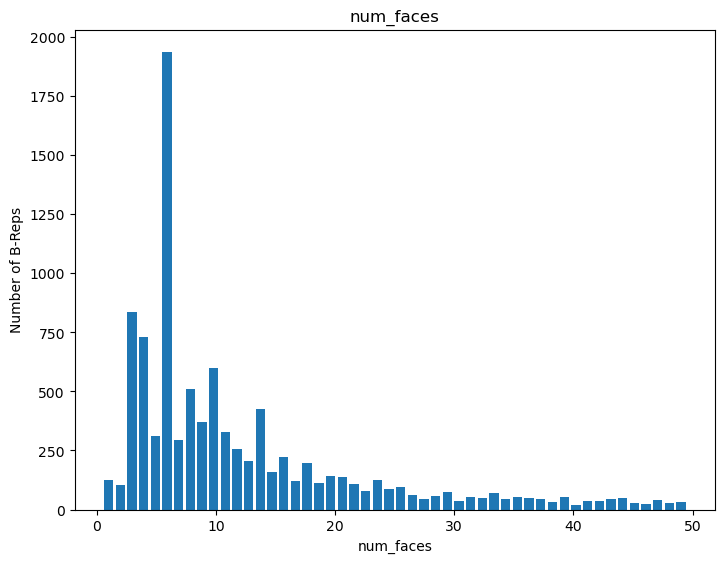

Max value 9349.   Min value 1
Truncating graph at 50


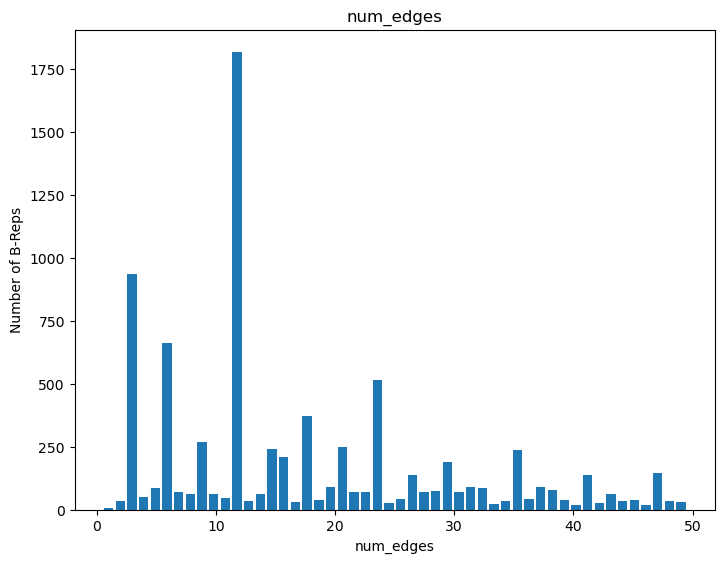

Max value 6068.   Min value 1
Truncating graph at 50


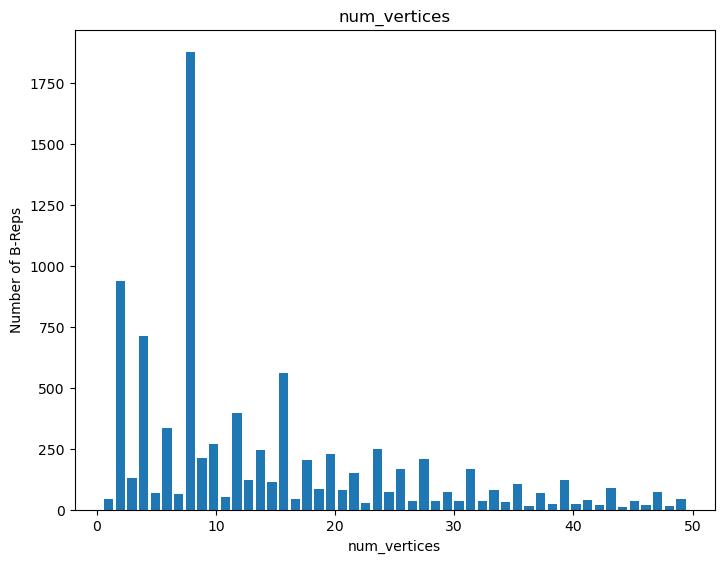

In [9]:
max_value = 50
for ent in entity_hist_data:
    plot_historgram(ent, entity_hist_data[ent], max_value=max_value, num_bins=max_value, xlabel=ent, ylabel="Number of B-Reps")

## Curve and surface types

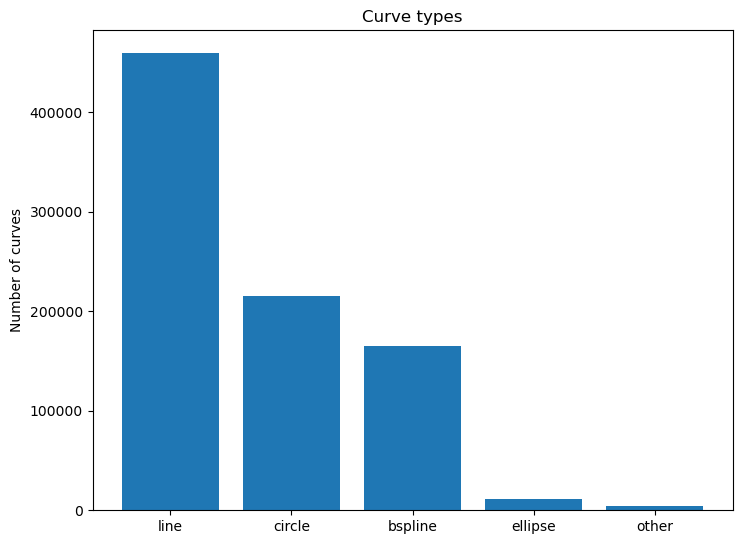

In [10]:
plot_bar_chart_for_counts("Curve types", curve_types_counter, ylabel="Number of curves", rotation=False)

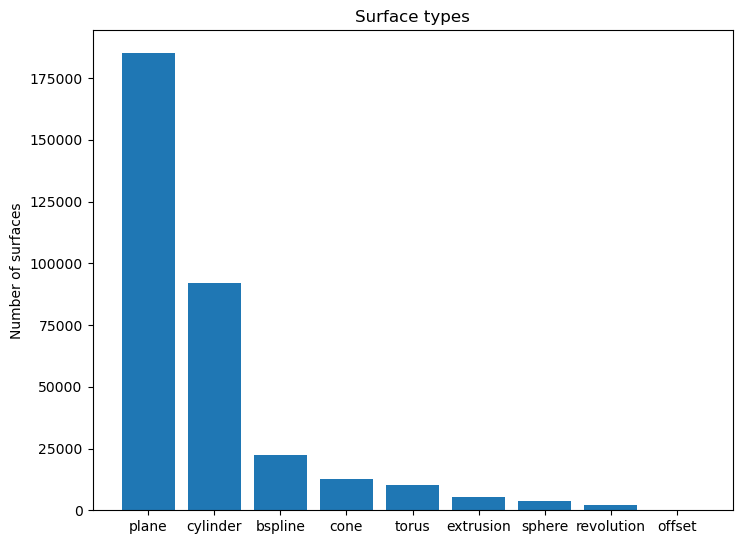

In [11]:
plot_bar_chart_for_counts("Surface types", surface_types_counter, ylabel="Number of surfaces", rotation=False)

Total number of bodies 11085
Number of prismatic bodies 3588
Prismatic percent 32.368064952638704%
Percent of non-prismatic bodies which can be approximated 0.06669334400426838
Max value 3505.   Min value 1
Truncating graph at 500


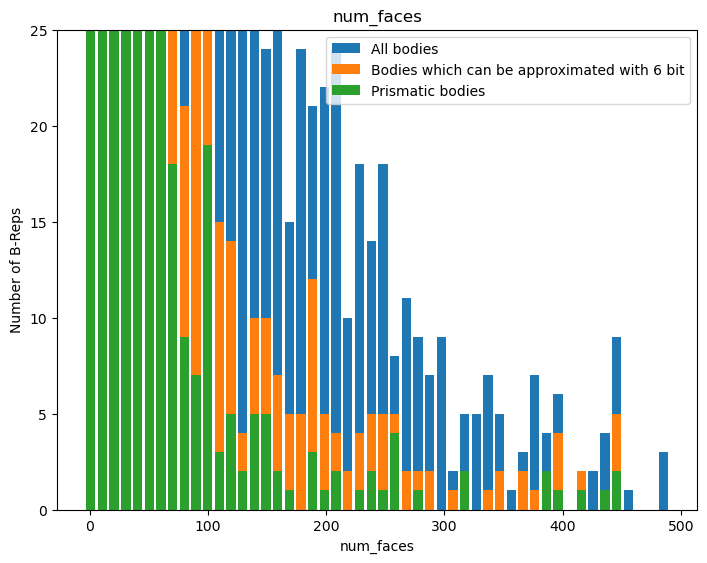

Max value 9349.   Min value 1
Truncating graph at 500


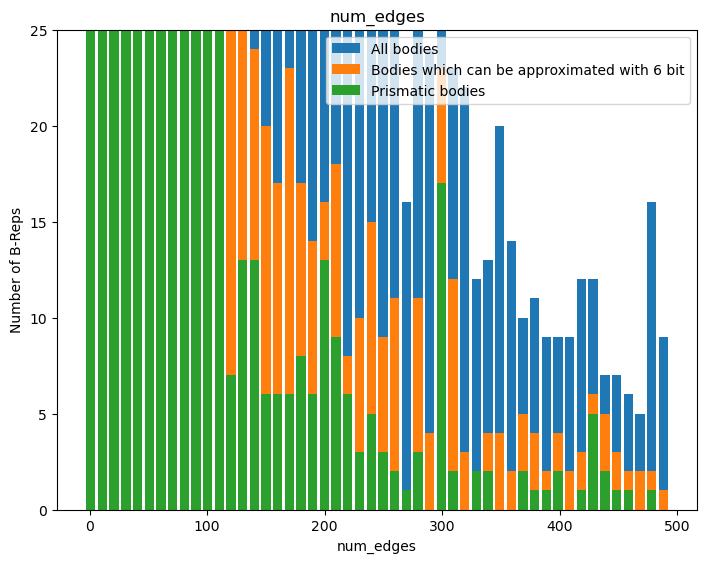

Max value 6068.   Min value 1
Truncating graph at 500


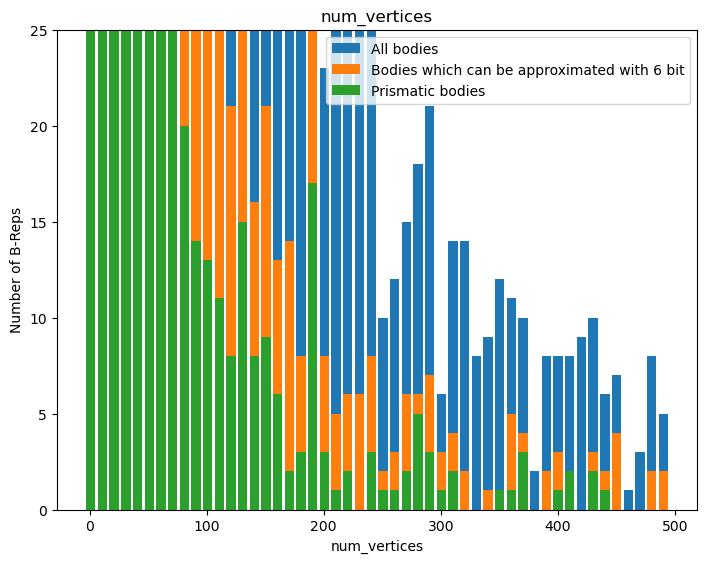

In [12]:
num_bodies_all = len(entity_hist_data[ent])
num_bodies_prismatic = len(prismatic_only_bodies[ent])
print(f"Total number of bodies {num_bodies_all}")
print(f"Number of prismatic bodies {num_bodies_prismatic}")
print(f"Prismatic percent {100*num_bodies_prismatic/num_bodies_all}%")
num_non_prismatic_bodies_which_can_be_approximated = len(non_prismatic_bodies_which_can_be_approximated)
num_non_prismatic_bodies = num_bodies_all - num_bodies_prismatic
print(f"Percent of non-prismatic bodies which can be approximated {100*num_non_prismatic_bodies_which_can_be_approximated/num_non_prismatic_bodies}")
    
for ent in entity_properties:
    data = {
        "All bodies": entity_hist_data[ent], 
        "Bodies which can be approximated with 6 bit": approximatable_bodies_6bit[ent],
        "Prismatic bodies": prismatic_only_bodies[ent]        
    }
    plot_historgram(ent, data, max_value=500, num_bins=50, ymax=25, xlabel=ent, ylabel="Number of B-Reps")

## Edge curve approximation

Total number of edges 856119
Total number of non-prismatic edges 181047
Total number of non-prismatic edges with edge curves 177046


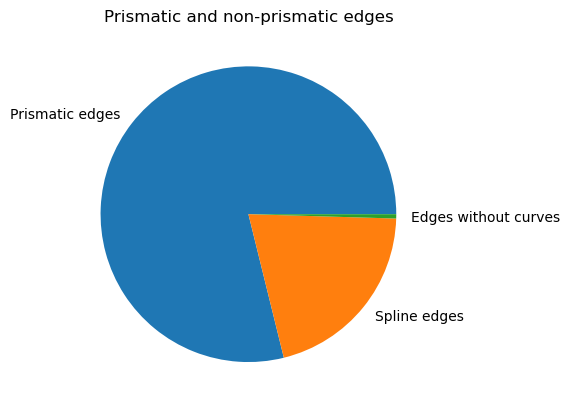

In [13]:
print(f"Total number of edges {all_edges}")
print(f"Total number of non-prismatic edges {all_non_prismatic_edges}")
print(f"Total number of non-prismatic edges with edge curves {all_non_prismatic_edges_with_curves}")
num_prismatic_edges = all_edges - all_non_prismatic_edges
num_prismatic_edges_without_curves = all_non_prismatic_edges-all_non_prismatic_edges_with_curves
plot_pie_chart("Prismatic and non-prismatic edges", 
               labels= ["Prismatic edges", "Spline edges", "Edges without curves"], 
               sizes=[num_prismatic_edges, all_non_prismatic_edges_with_curves, num_prismatic_edges_without_curves]
)

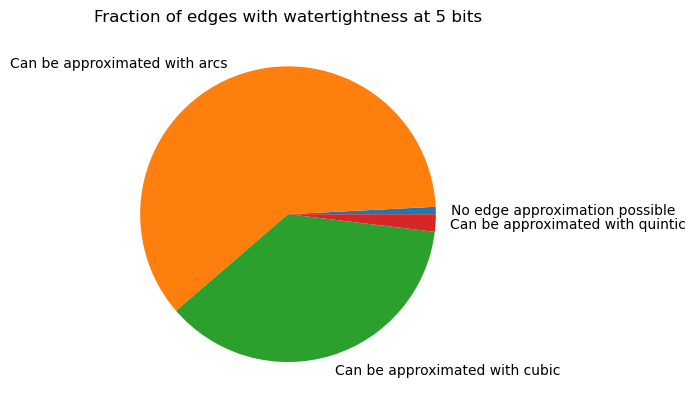

Percentage which cannot be approximated 0.80148661929668


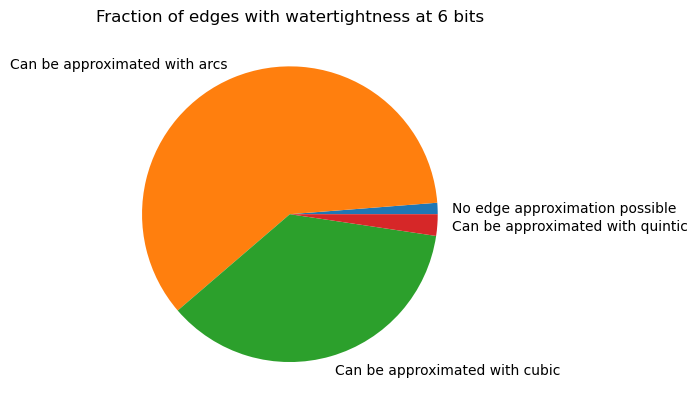

Percentage which cannot be approximated 1.2375314889915616


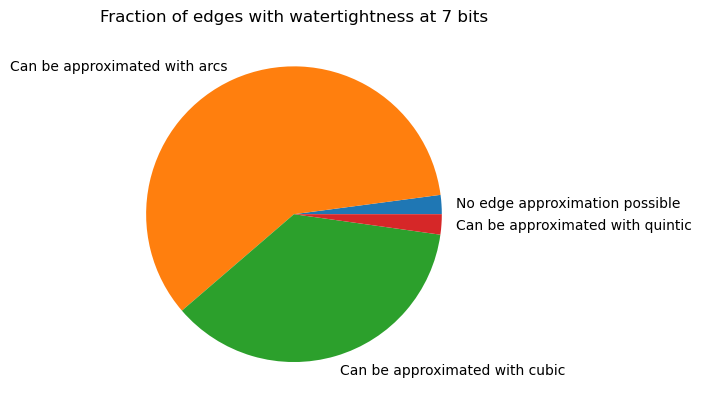

Percentage which cannot be approximated 2.090982004676751


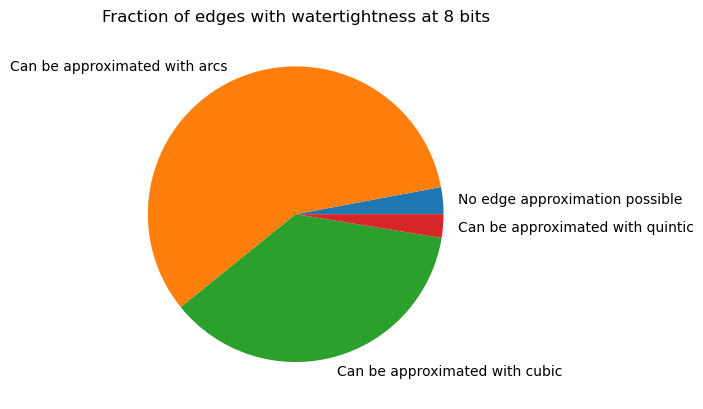

Percentage which cannot be approximated 2.9427380454797056


In [14]:
for b in tols:
    title = f"Fraction of edges with watertightness at {b} bits"
    num_approx_with_arcs = arc_approx_for_tol[b]
    num_approx_with_cubic = cubic_spline_approx_for_tol[b]
    num_approx_with_quintic = quintic_spline_approx_for_tol[b]
    no_edge_approx = no_edge_approx_for_tol[b]
    plot_pie_chart(title, 
               labels= ["No edge approximation possible", "Can be approximated with arcs", "Can be approximated with cubic", "Can be approximated with quintic"], 
               sizes=[no_edge_approx, num_approx_with_arcs, num_approx_with_cubic, num_approx_with_quintic]
    )    
    print(f"Percentage which cannot be approximated {100*no_edge_approx/all_non_prismatic_edges_with_curves}")

## Approxmation of surfaces

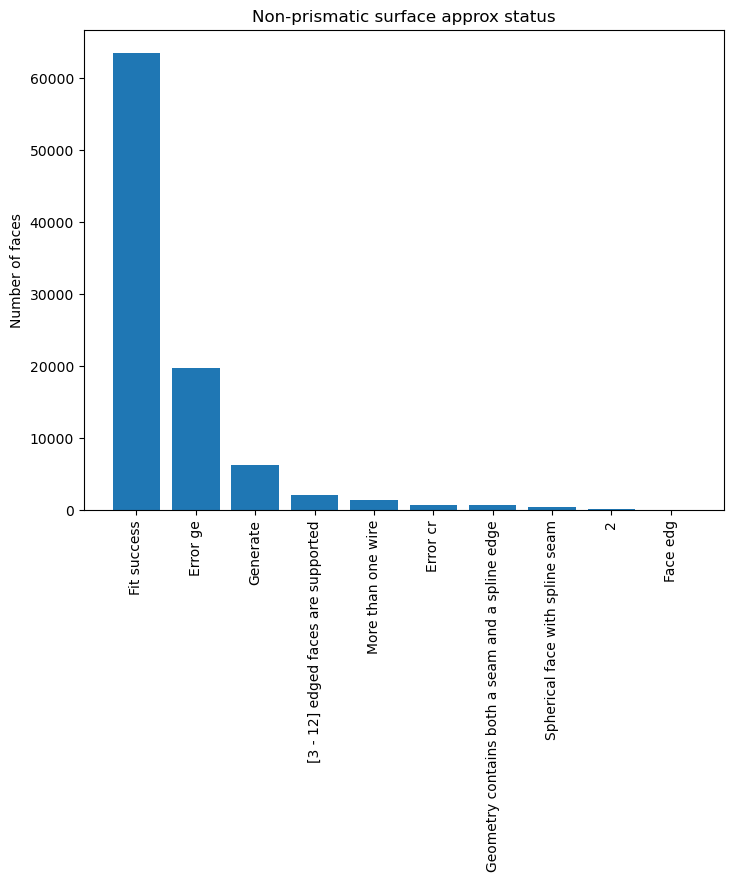

In [15]:
non_prismatic_surface_approximations_status = Counter(non_prismatic_surface_approximations_status)
plot_bar_chart_for_counts(
    "Non-prismatic surface approx status", 
    non_prismatic_surface_approximations_status, 
    ylabel="Number of faces", 
    rotation=True
)

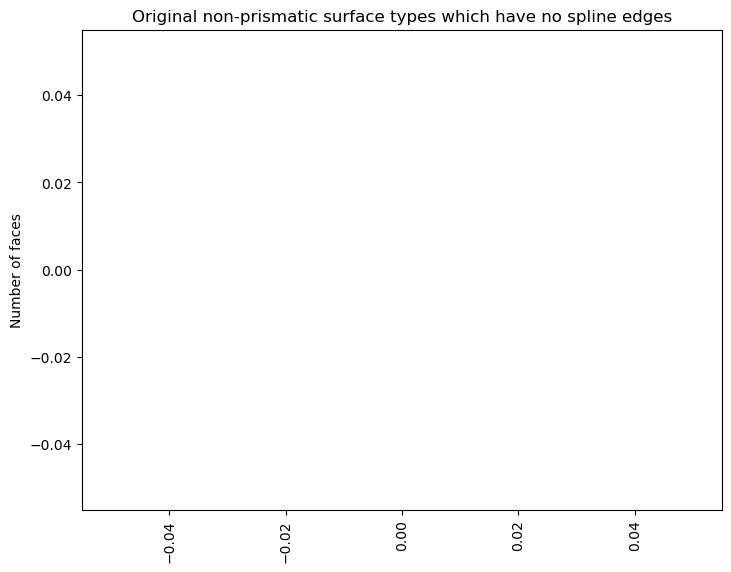

In [16]:
no_spline_edge_surface_types =  Counter(no_spline_edge_surface_types)
plot_bar_chart_for_counts(
    "Original non-prismatic surface types which have no spline edges", 
    no_spline_edge_surface_types, 
    ylabel="Number of faces", 
    rotation=True
)

Percentage of non-prismatic fit ok but out of tol at 5 bit 1.6554830986359197


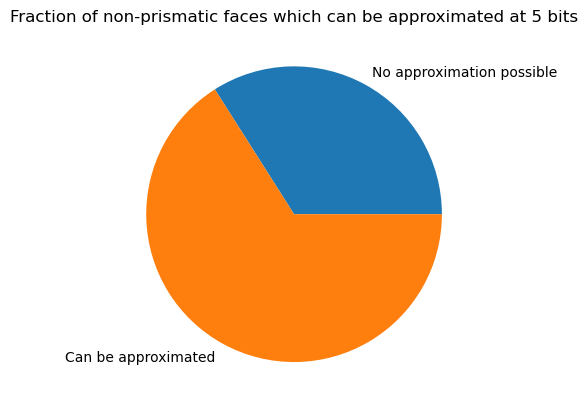

Fraction of non-prismatic faces good for SolidGen 66.00173368852806%


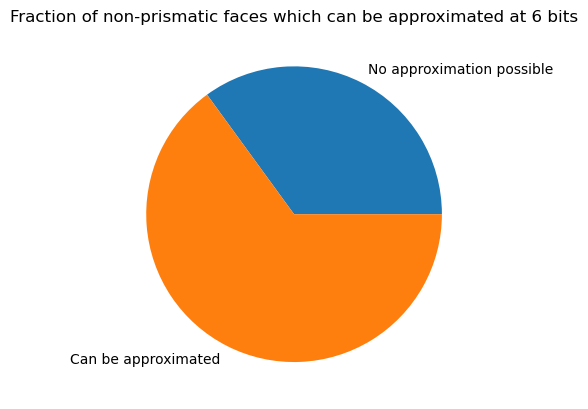

Fraction of non-prismatic faces good for SolidGen 64.98266311471944%


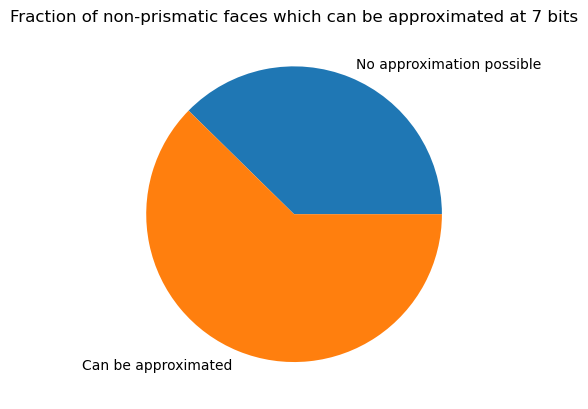

Fraction of non-prismatic faces good for SolidGen 62.353587889551356%


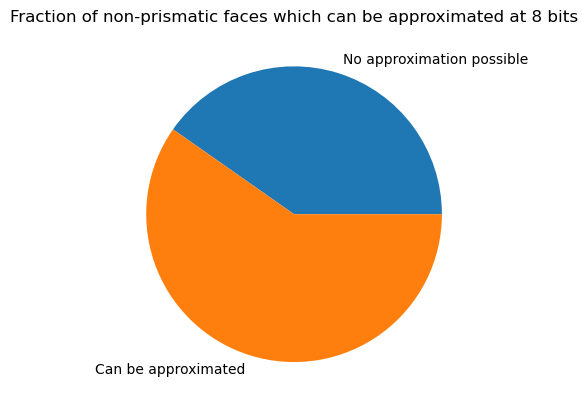

Fraction of non-prismatic faces good for SolidGen 59.73085542729079%


In [17]:
print(f"Percentage of non-prismatic fit ok but out of tol at 5 bit {100*num_np_faces_out_of_tol/num_np_faces_fit_ok}")
for b in tols:
    title = f"Fraction of non-prismatic faces which can be approximated at {b} bits"
    np_faces_good_for_solidgen = surface_approx_for_tol[b]
    np_faces_cant_be_approximated = no_surf_approx_for_tol[b]
    assert np_faces_good_for_solidgen + np_faces_cant_be_approximated == num_np_faces_all, "Missing faces"
    
    plot_pie_chart(title, 
               labels= ["No approximation possible", "Can be approximated"], 
               sizes=[np_faces_cant_be_approximated, np_faces_good_for_solidgen]
    )
    print(f"Fraction of non-prismatic faces good for SolidGen {100*np_faces_good_for_solidgen/(np_faces_cant_be_approximated+np_faces_good_for_solidgen)}%")

Max value 840.   Min value 1
Truncating graph at 30


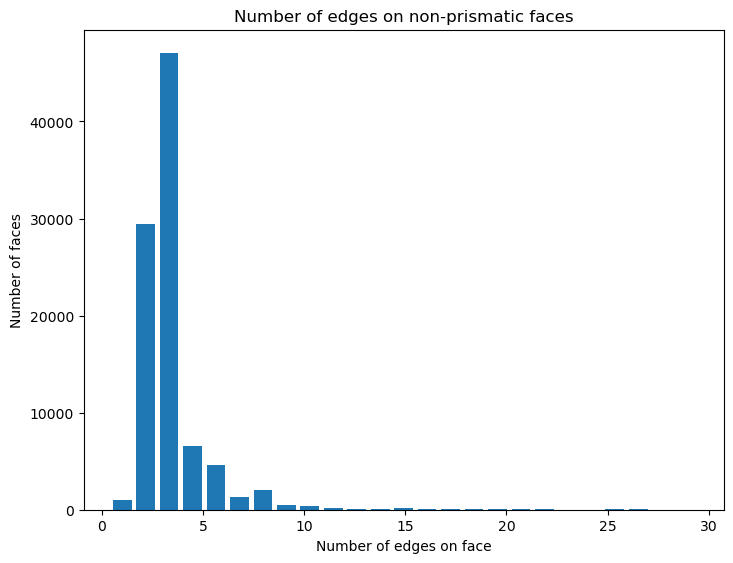

In [18]:
plot_historgram("Number of edges on non-prismatic faces", num_edges_on_non_prismatic_faces, max_value=30, num_bins=25, xlabel="Number of edges on face", ylabel="Number of faces")

## Body approximation to tolerance

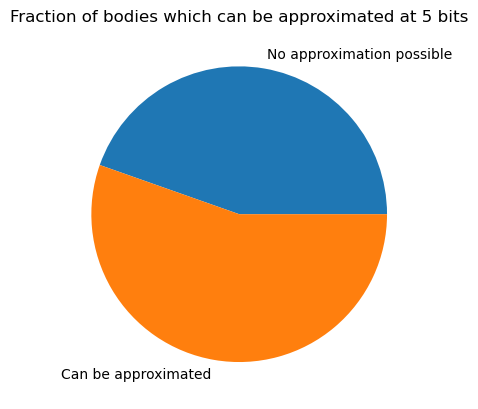

Fraction of bodies good for SolidGen 55.39918809201624%


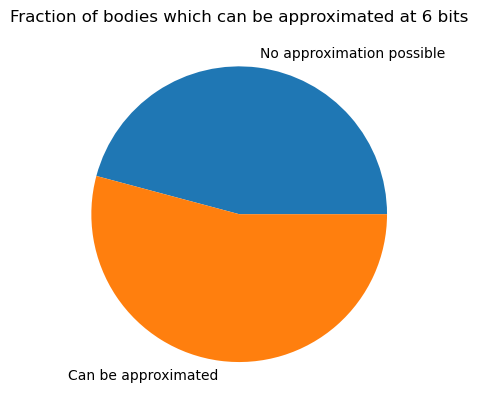

Fraction of bodies good for SolidGen 54.16328371673433%


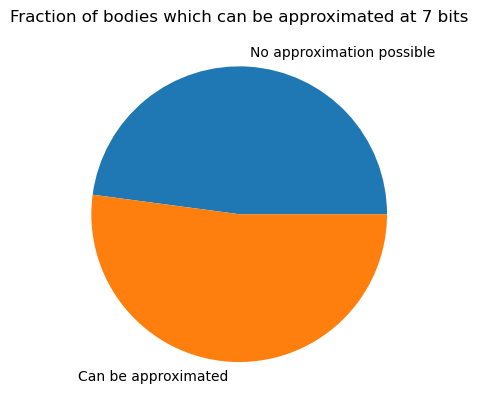

Fraction of bodies good for SolidGen 52.106450157870995%


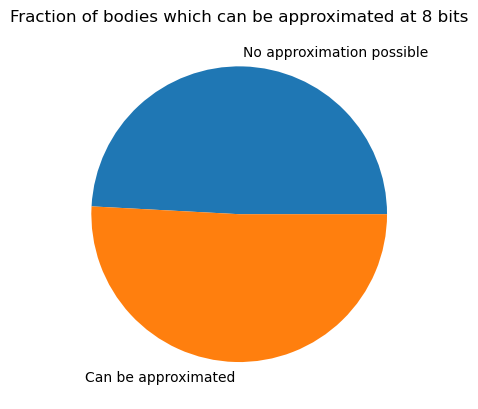

Fraction of bodies good for SolidGen 50.843482183130355%


In [19]:
for b in tols:
    title = f"Fraction of bodies which can be approximated at {b} bits"
    bodies_good_for_solidgen = bodies_approx_for_tol[b]
    bodies_cant_be_approximated = bodies_cant_approx_for_tol[b]
    assert bodies_good_for_solidgen + bodies_cant_be_approximated == num_bodies_all, "Missing solids"
    plot_pie_chart(title, 
               labels= ["No approximation possible", "Can be approximated"], 
               sizes=[bodies_cant_be_approximated, bodies_good_for_solidgen]
    )
    print(f"Fraction of bodies good for SolidGen {100*bodies_good_for_solidgen/(bodies_good_for_solidgen+bodies_cant_be_approximated)}%")

## Gallery

Very small (num_faces <= 6) prismatic bodies (can be approximated)

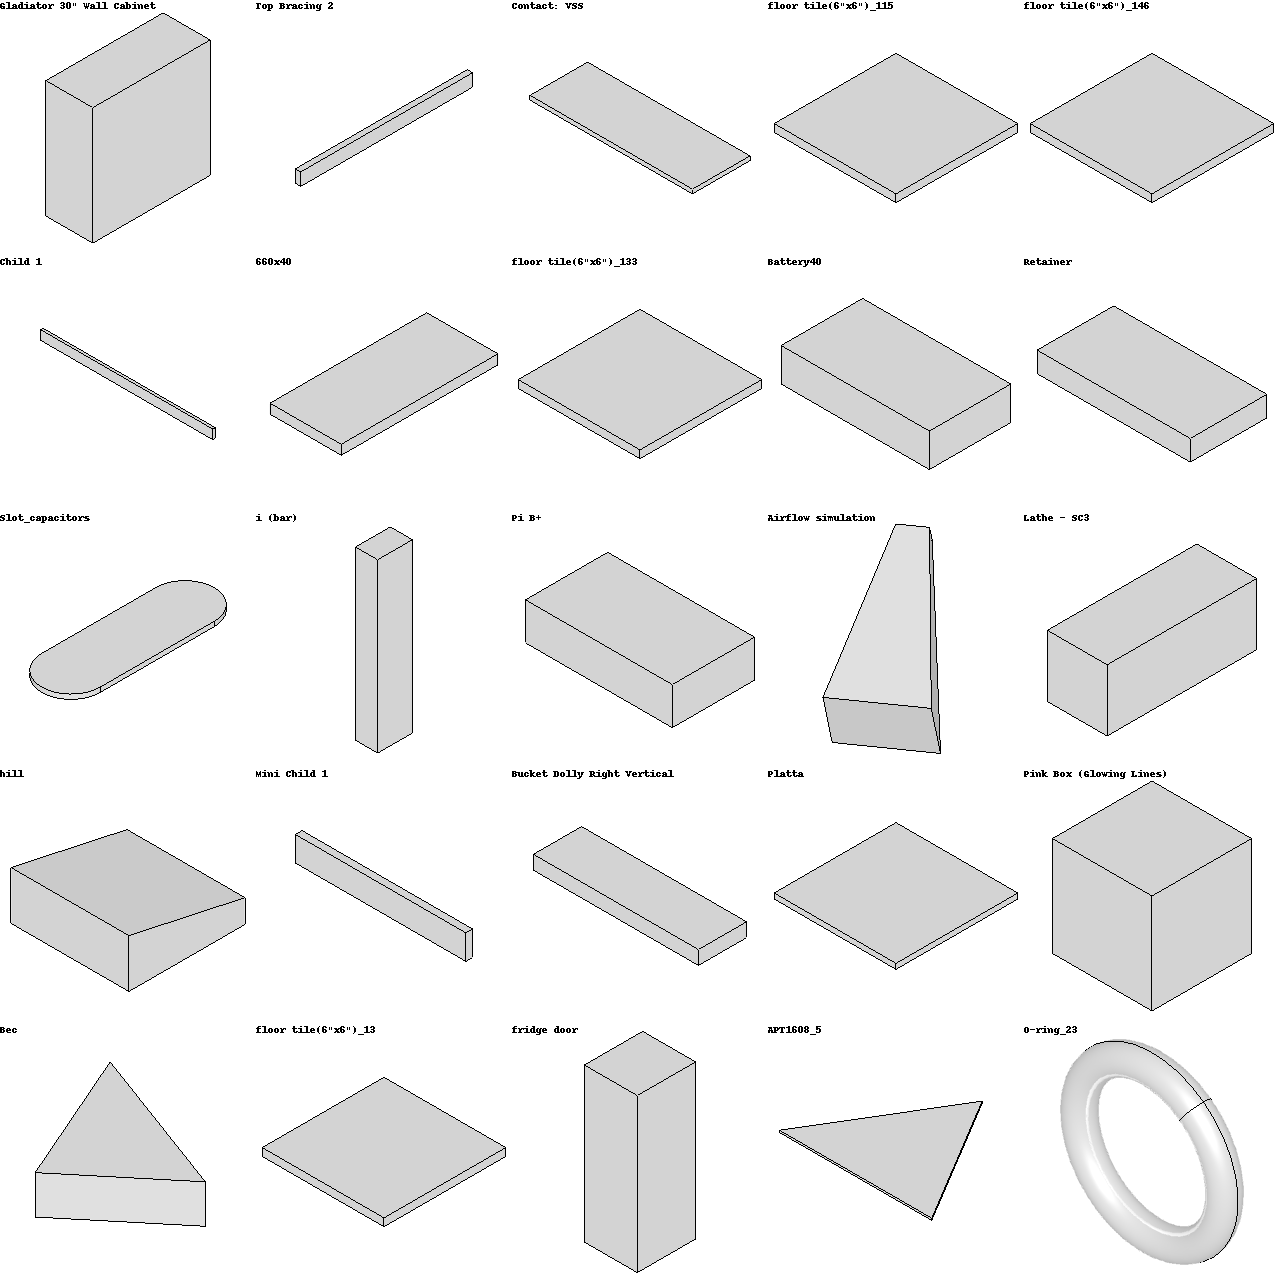

Very small (num_faces <= 6) non-prismatic bodies which can be approximated

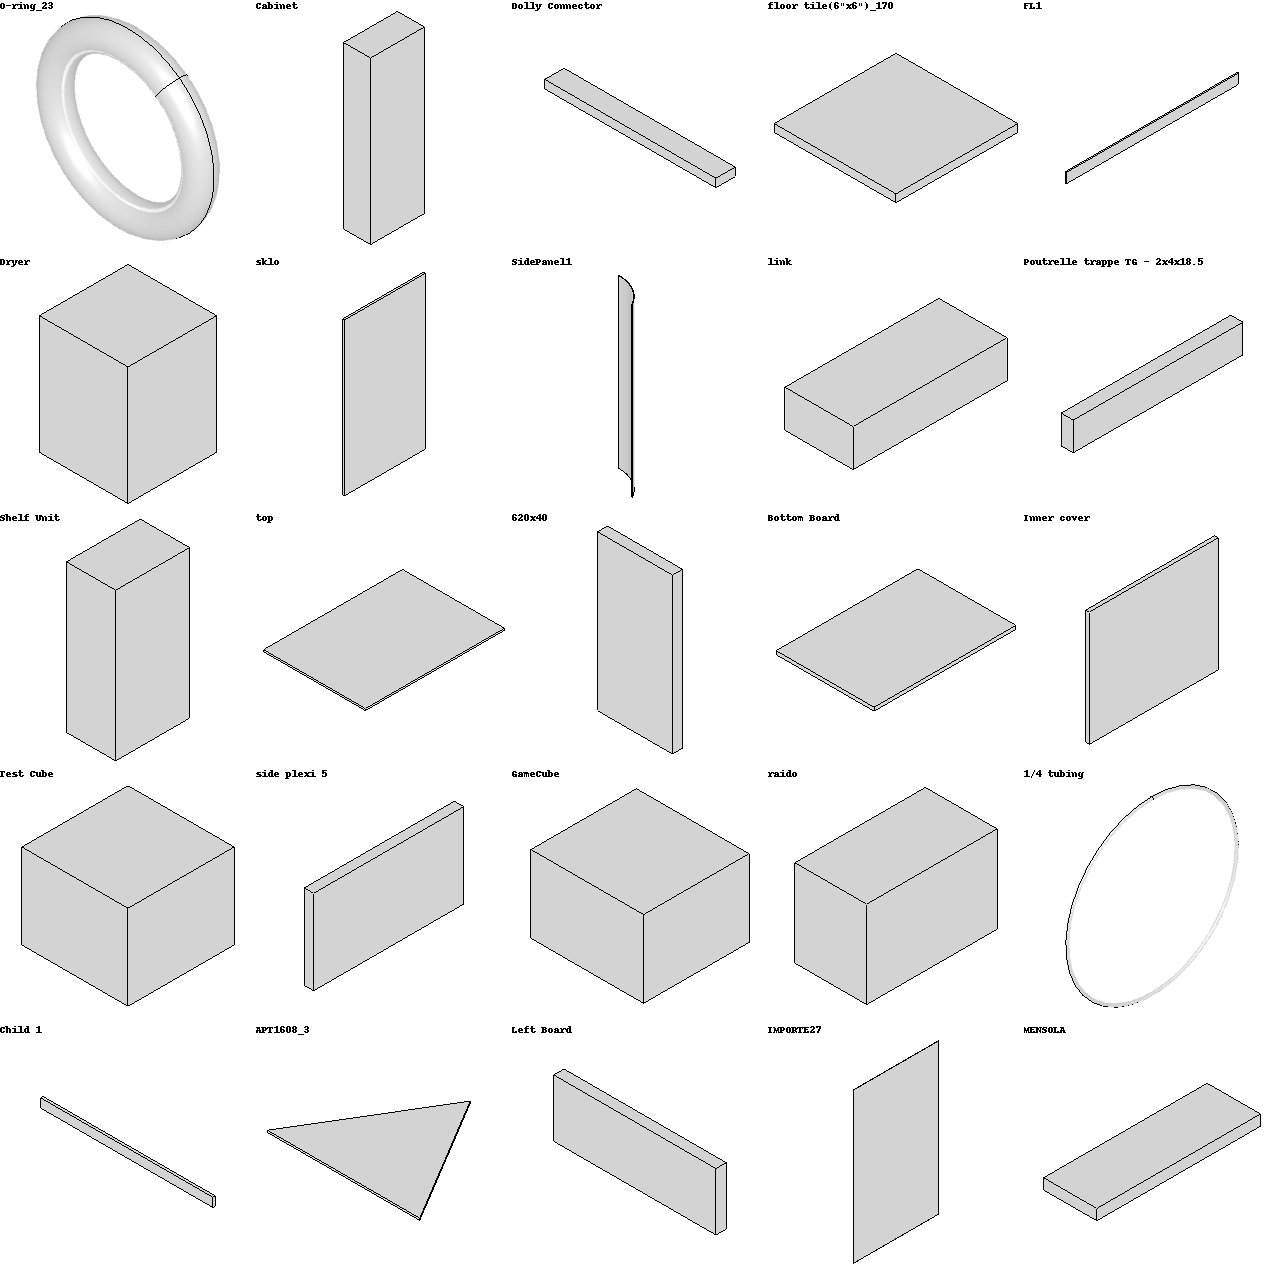

Very small (num_faces <= 6) non-prismatic bodies which can't be approximated

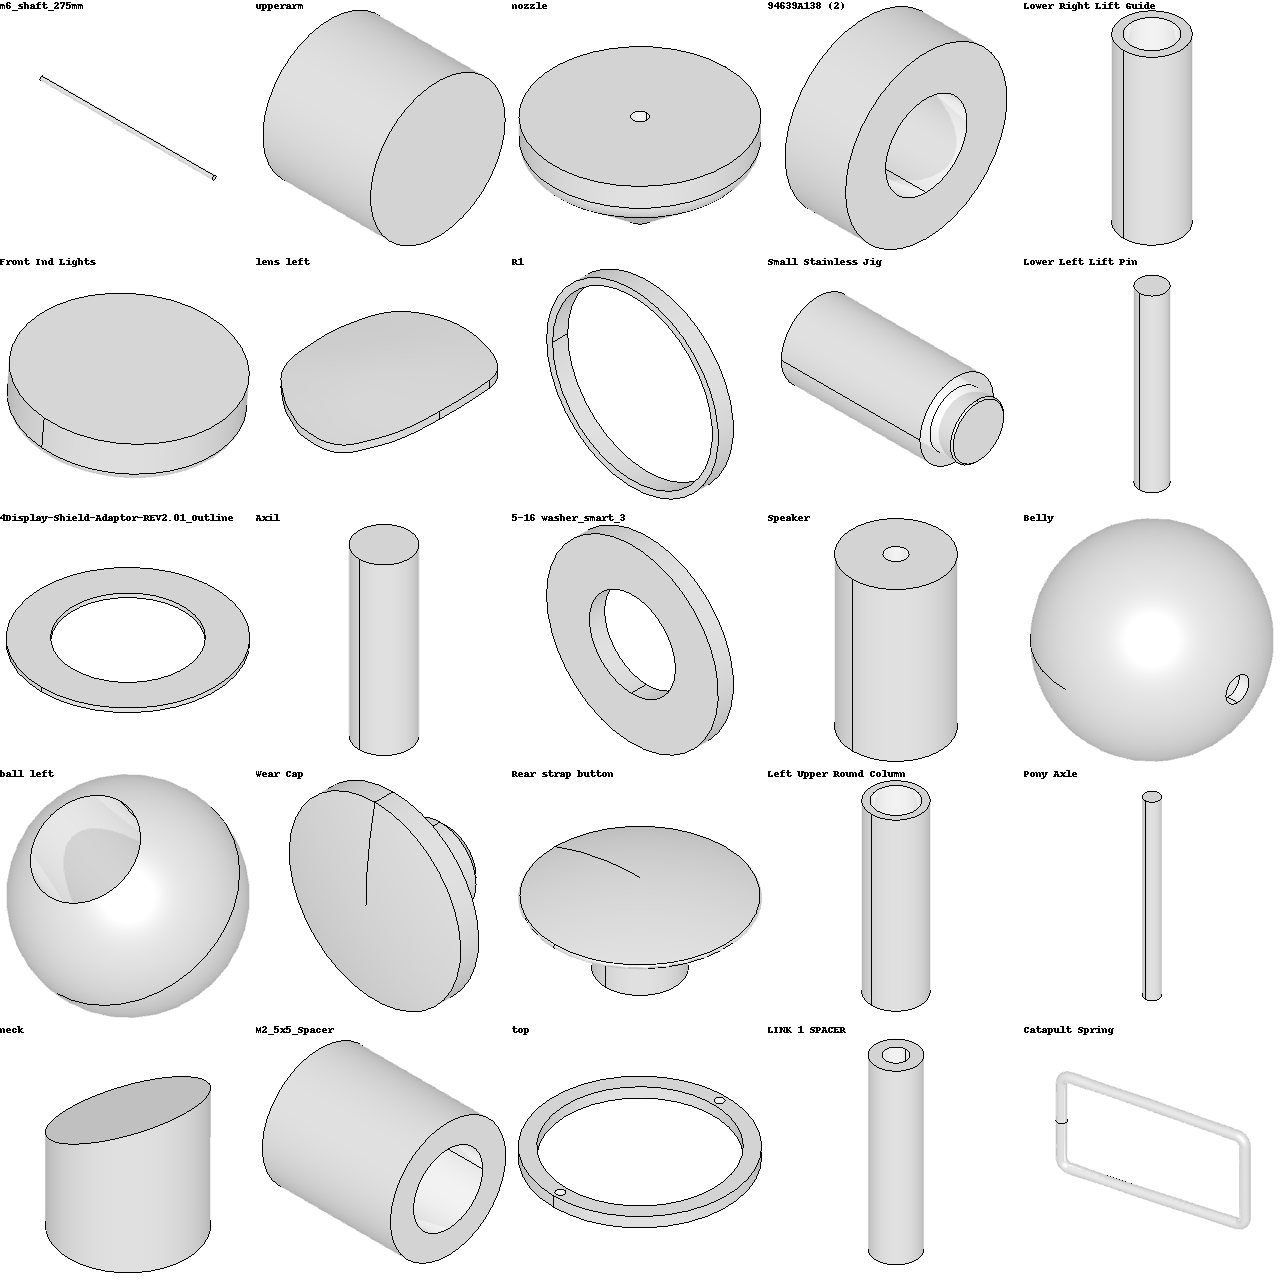

Small (6 < num_faces <= 30) prismatic bodies (can be approximated)

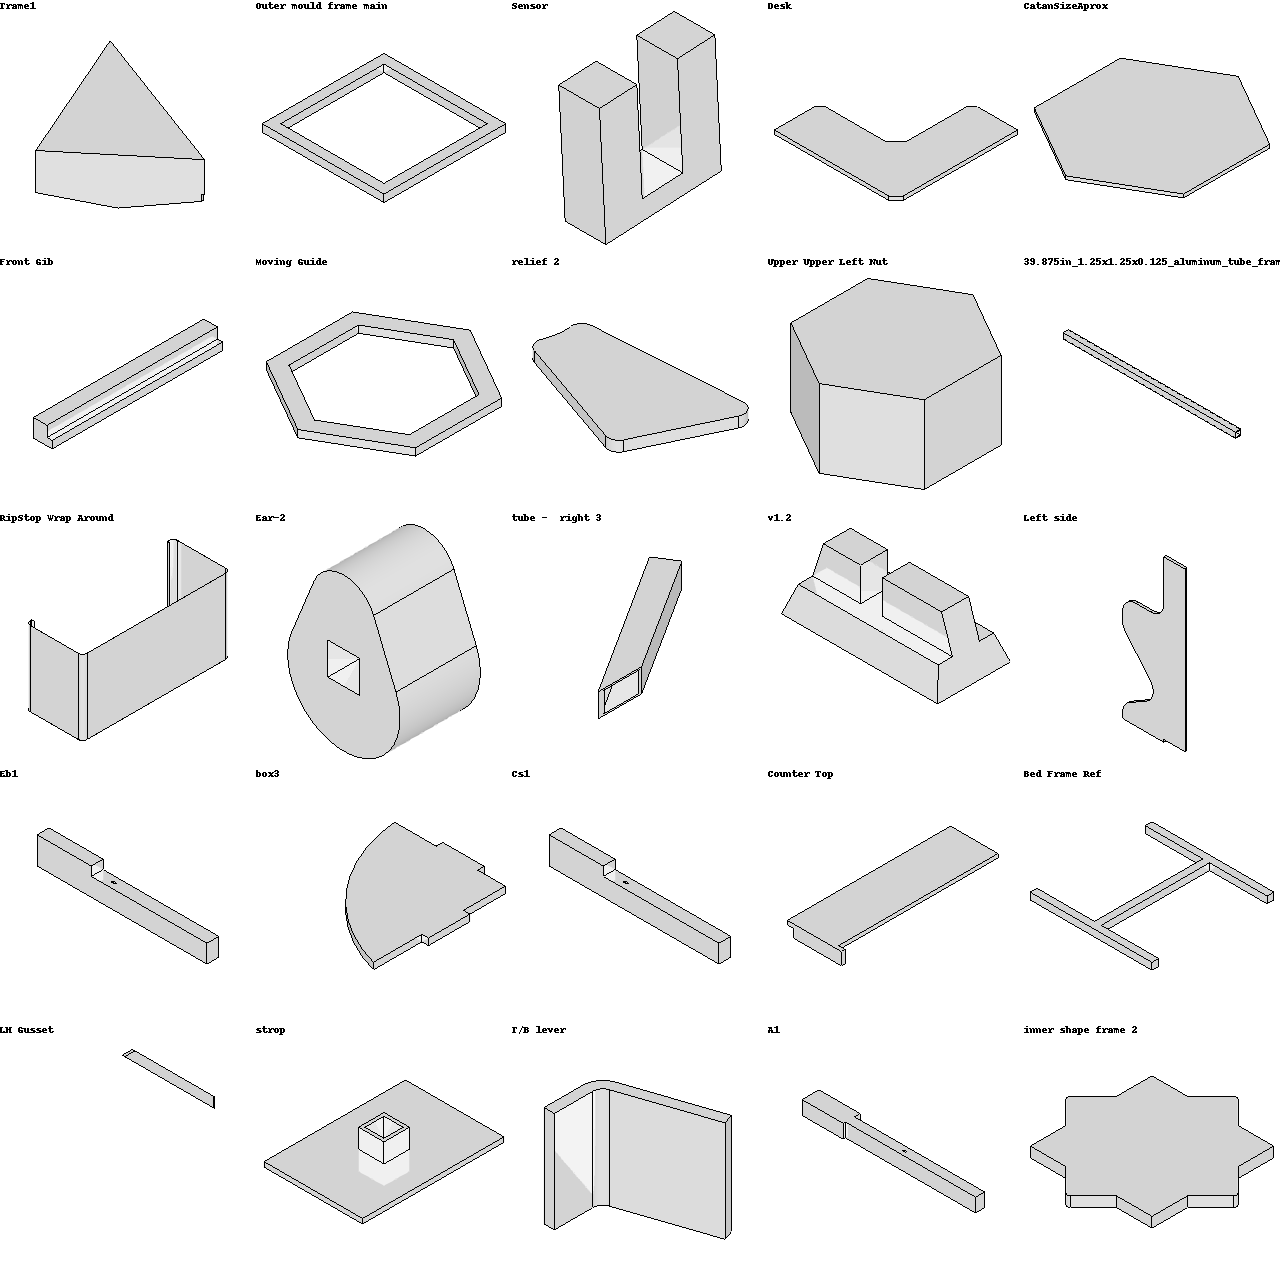

Small (6 < num_faces <= 30) non-prismatic bodies which can be approximated

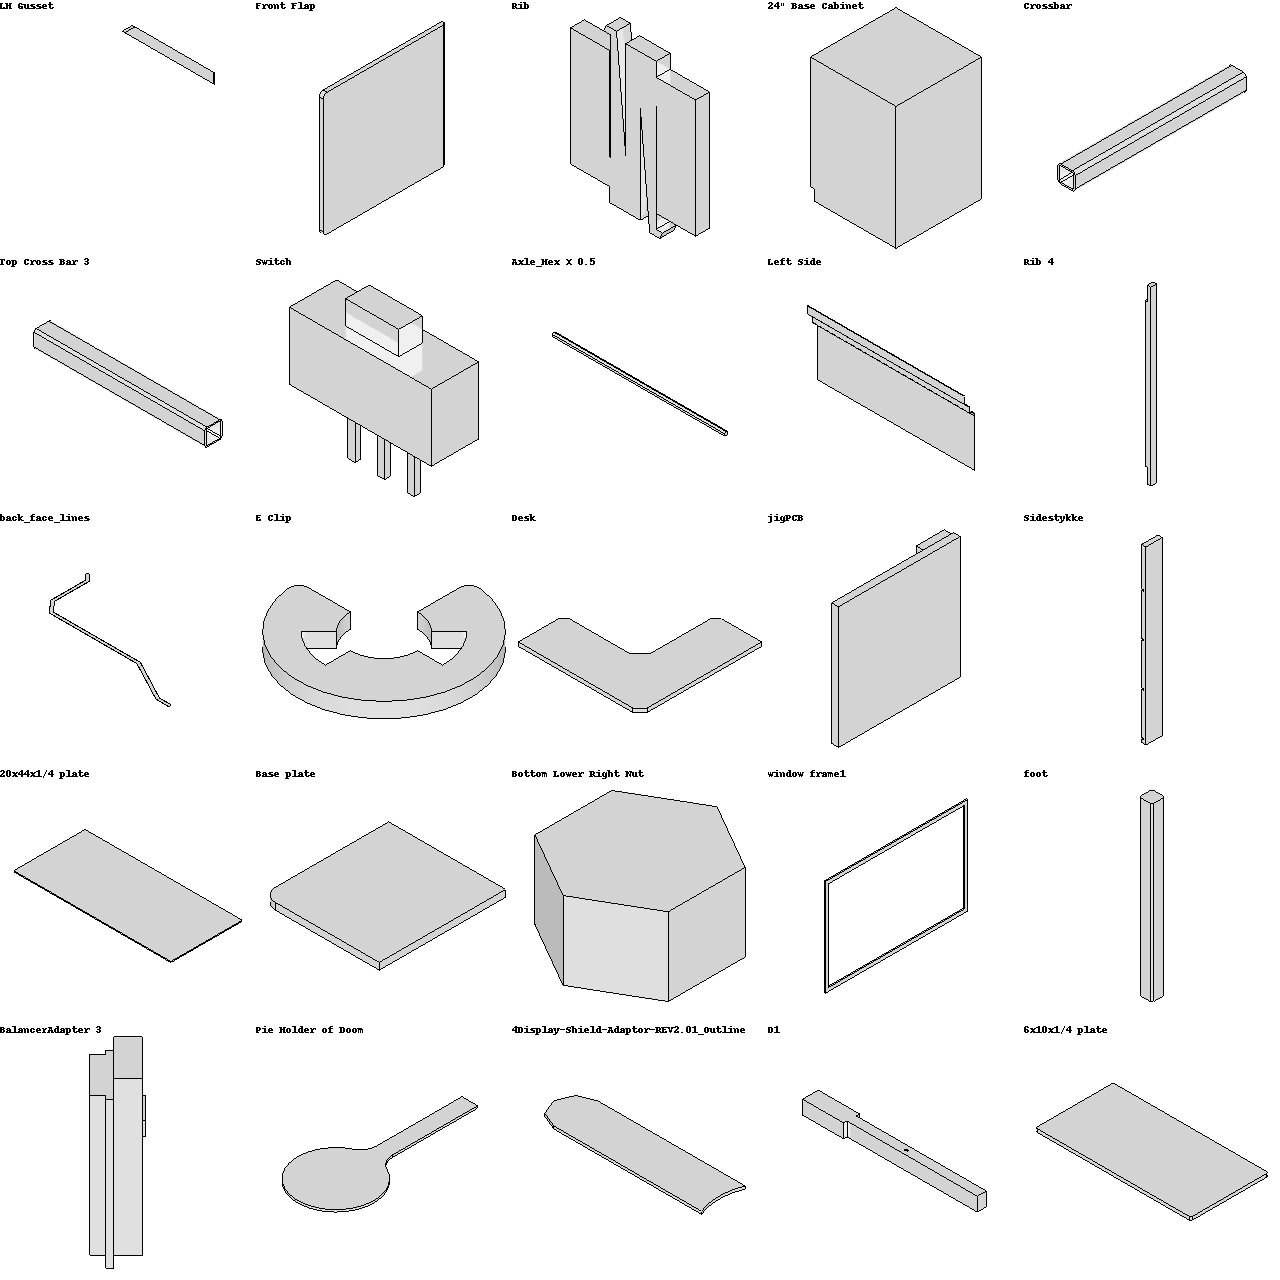

Small (6 < num_faces <= 30) non-prismatic bodies which can't be approximated

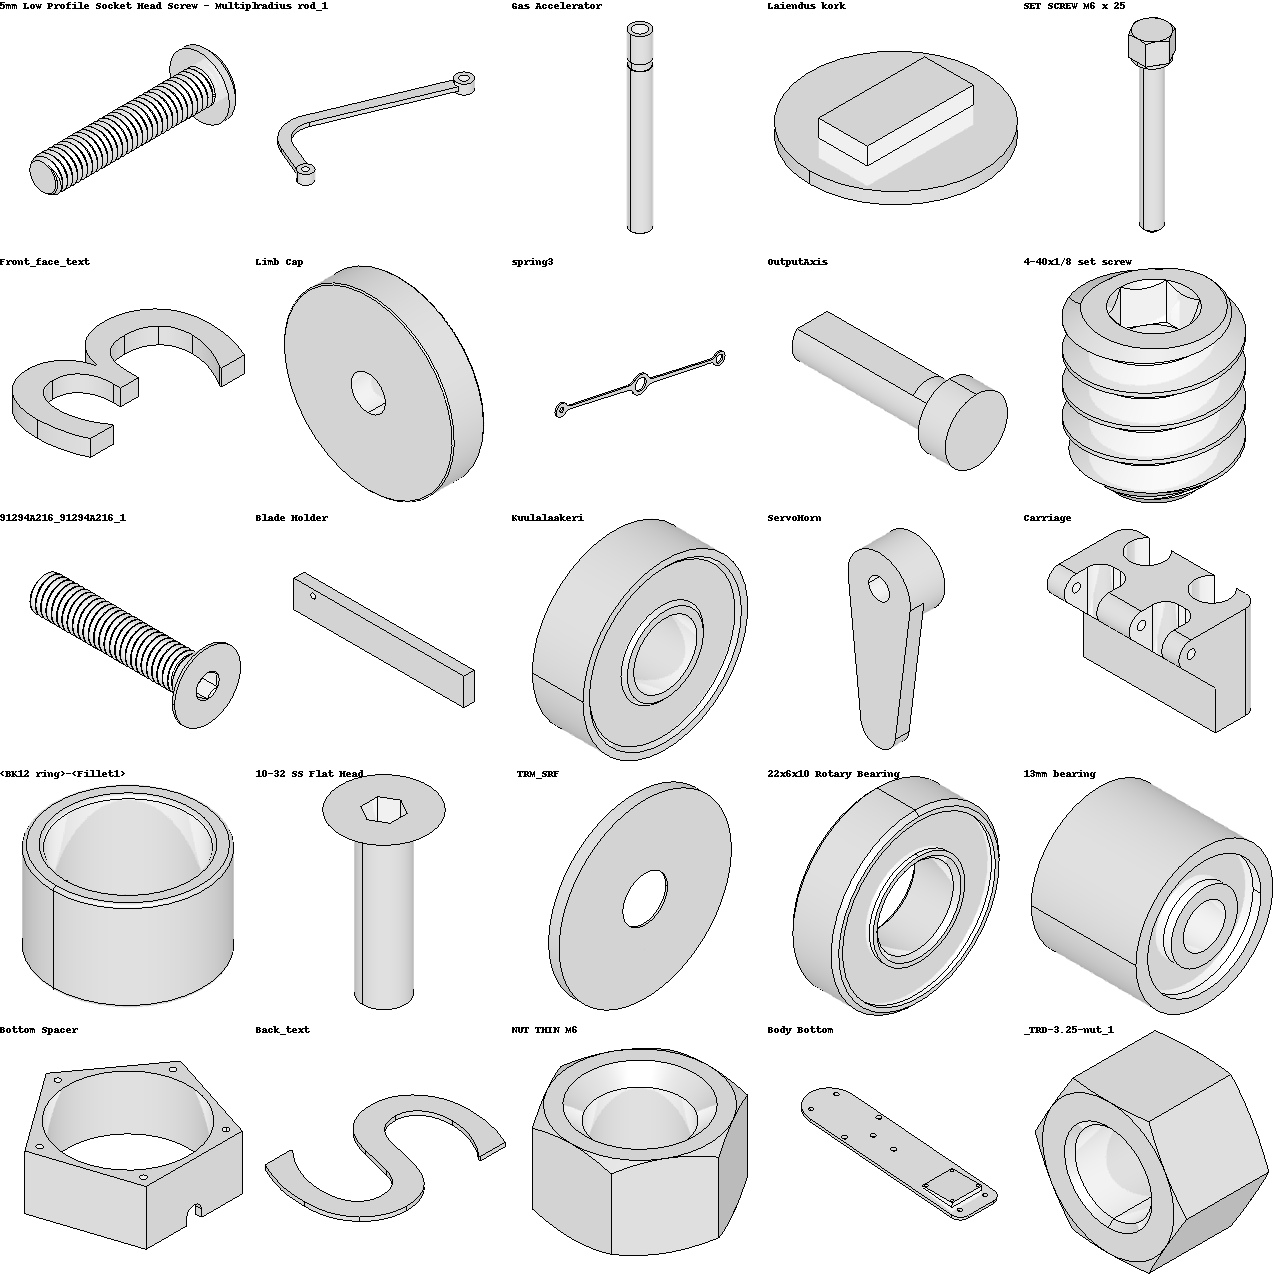

Medium (30 < num_faces <= 100) prismatic bodies (can be approximated)

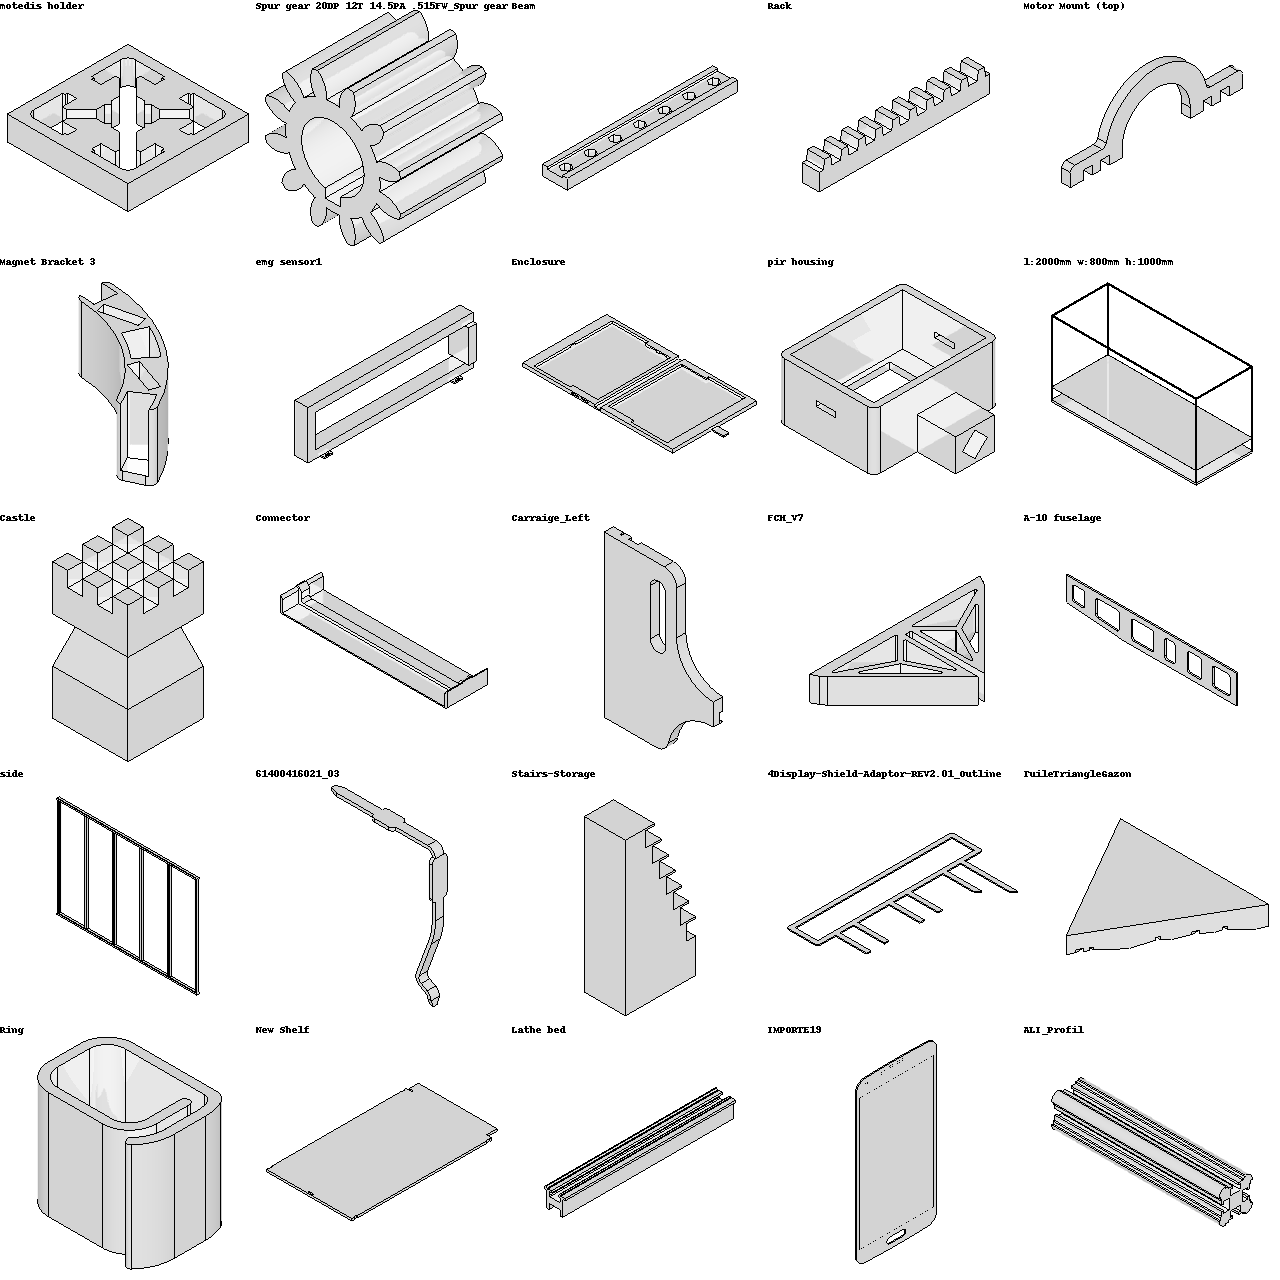

Medium (30 < num_faces <= 100) non-prismatic bodies which can be approximated

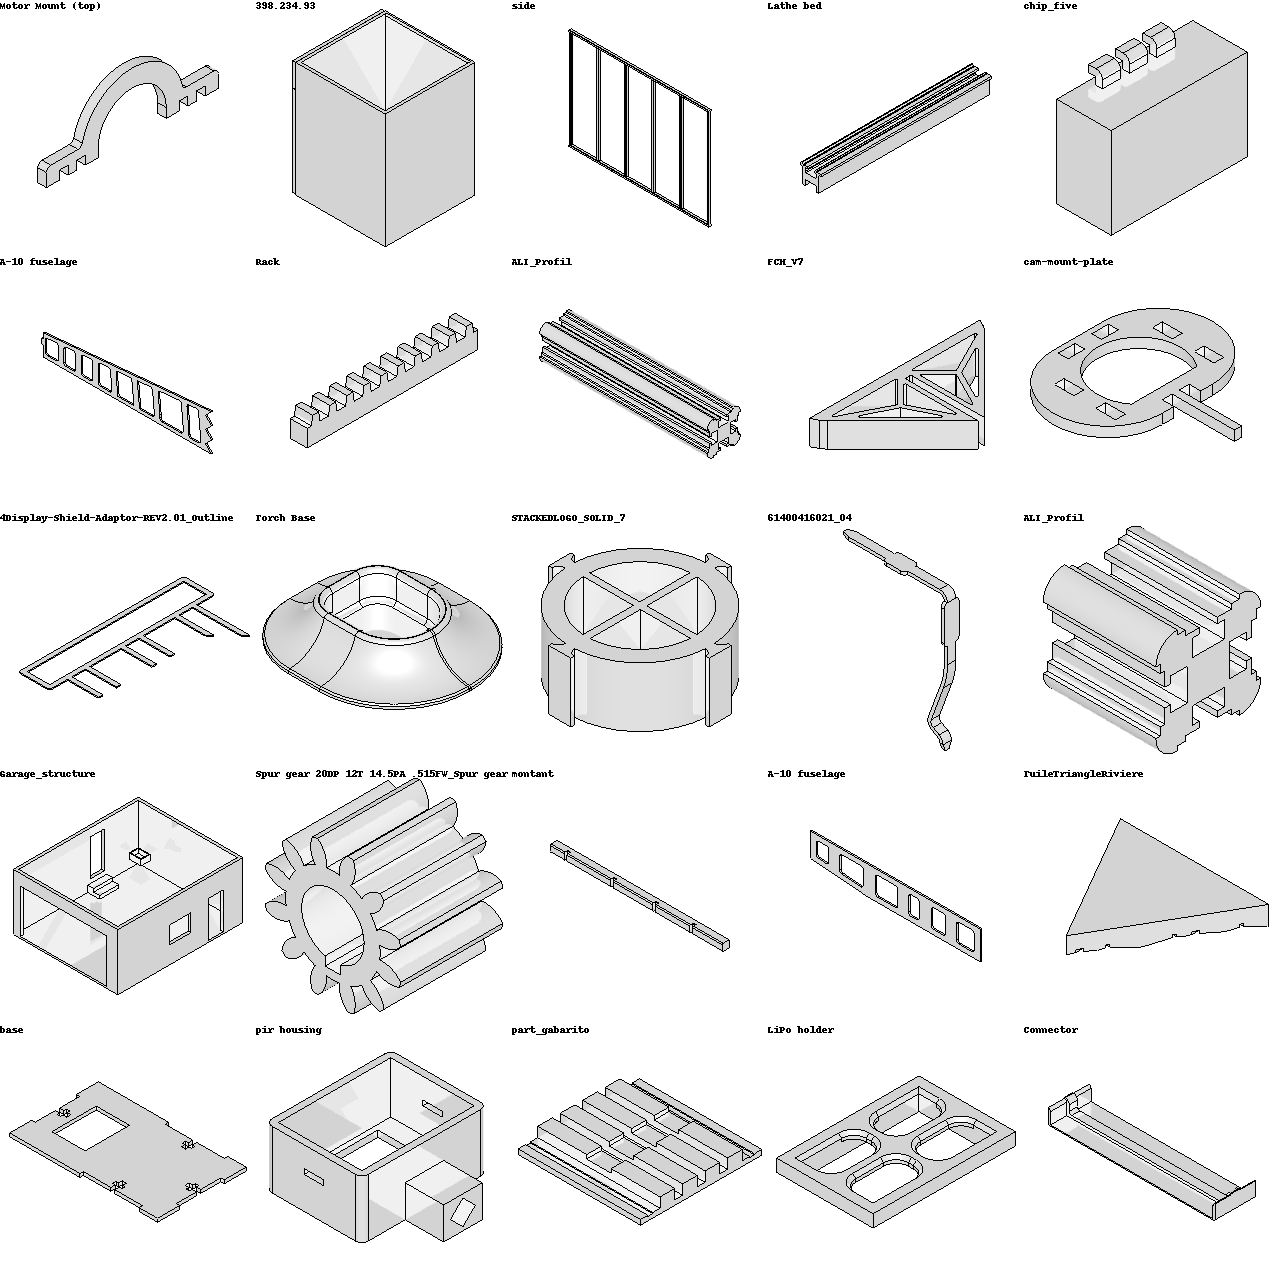

Medium (30 < num_faces <= 100) non-prismatic bodies which can't be approximated

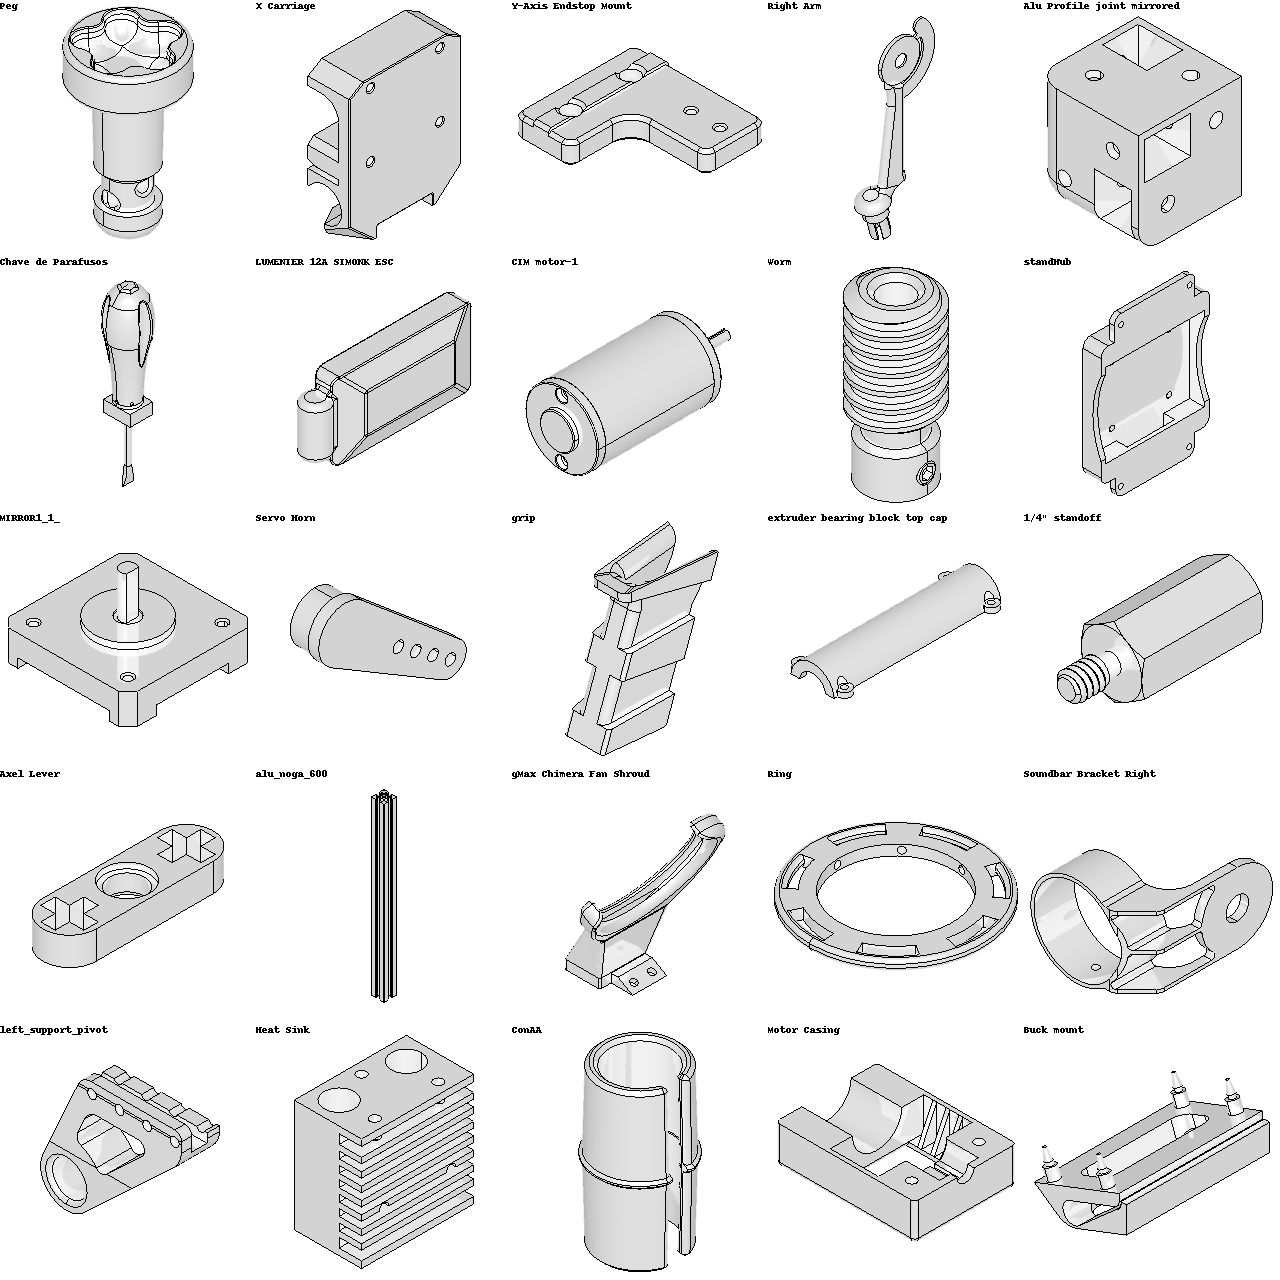

Large (100 < num_faces <= 300) prismatic bodies (can be approximated)

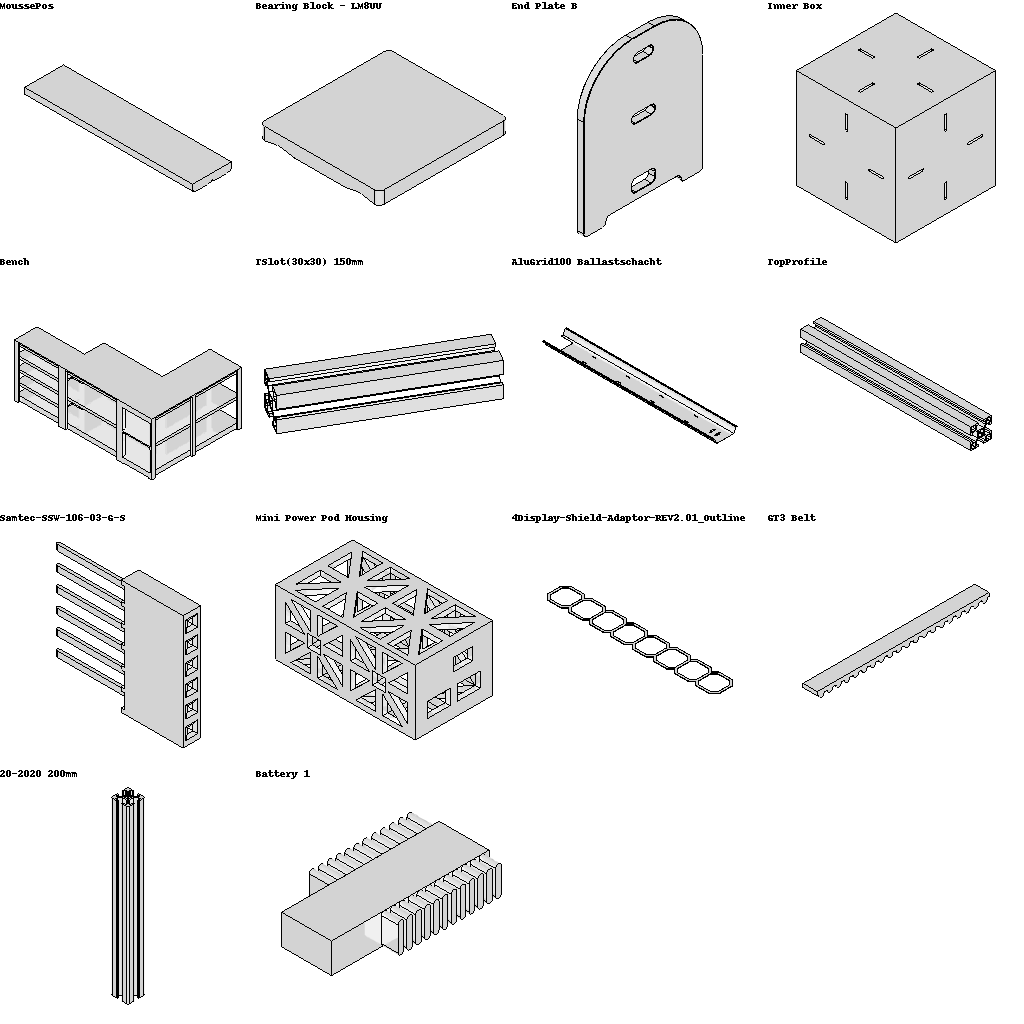

Large (100 < num_faces <= 300) non-prismatic bodies which can be approximated

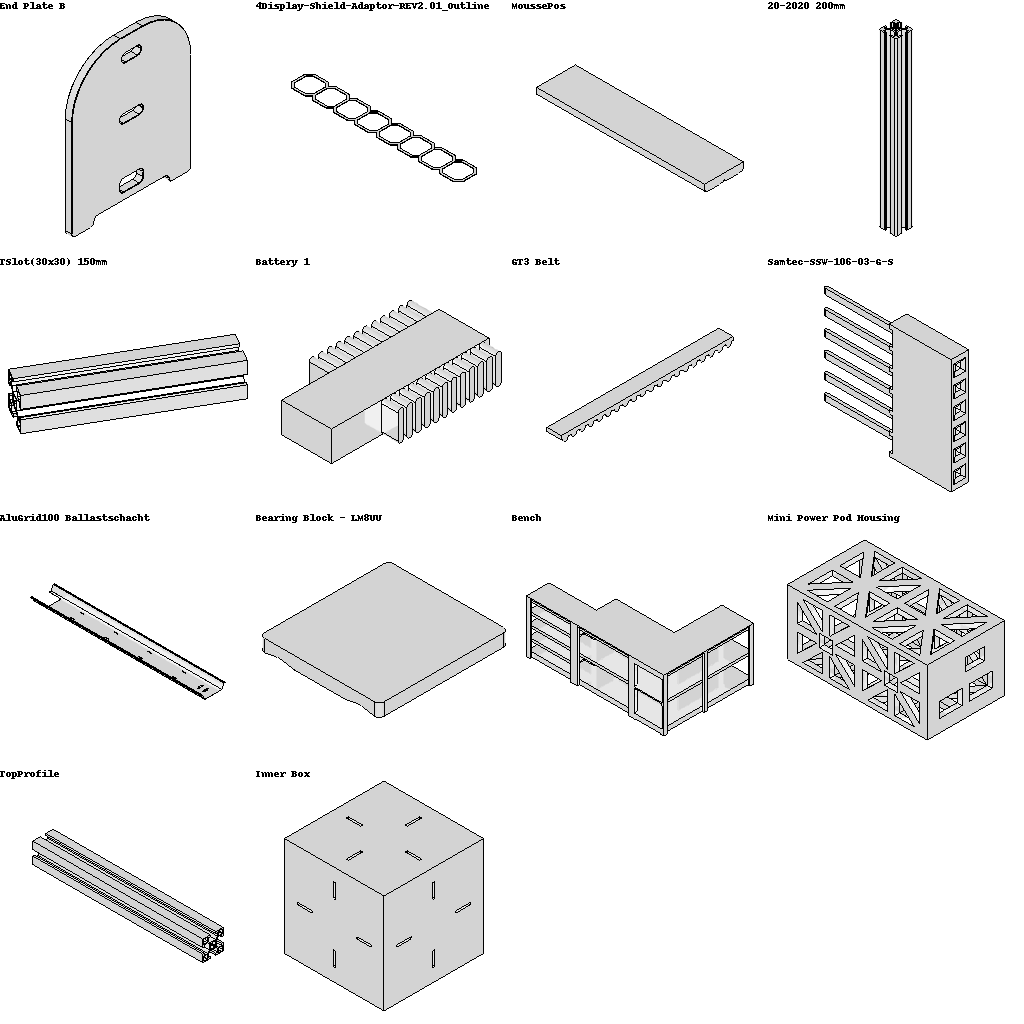

Large (100 < num_faces <= 300) non-prismatic bodies which can't be approximated

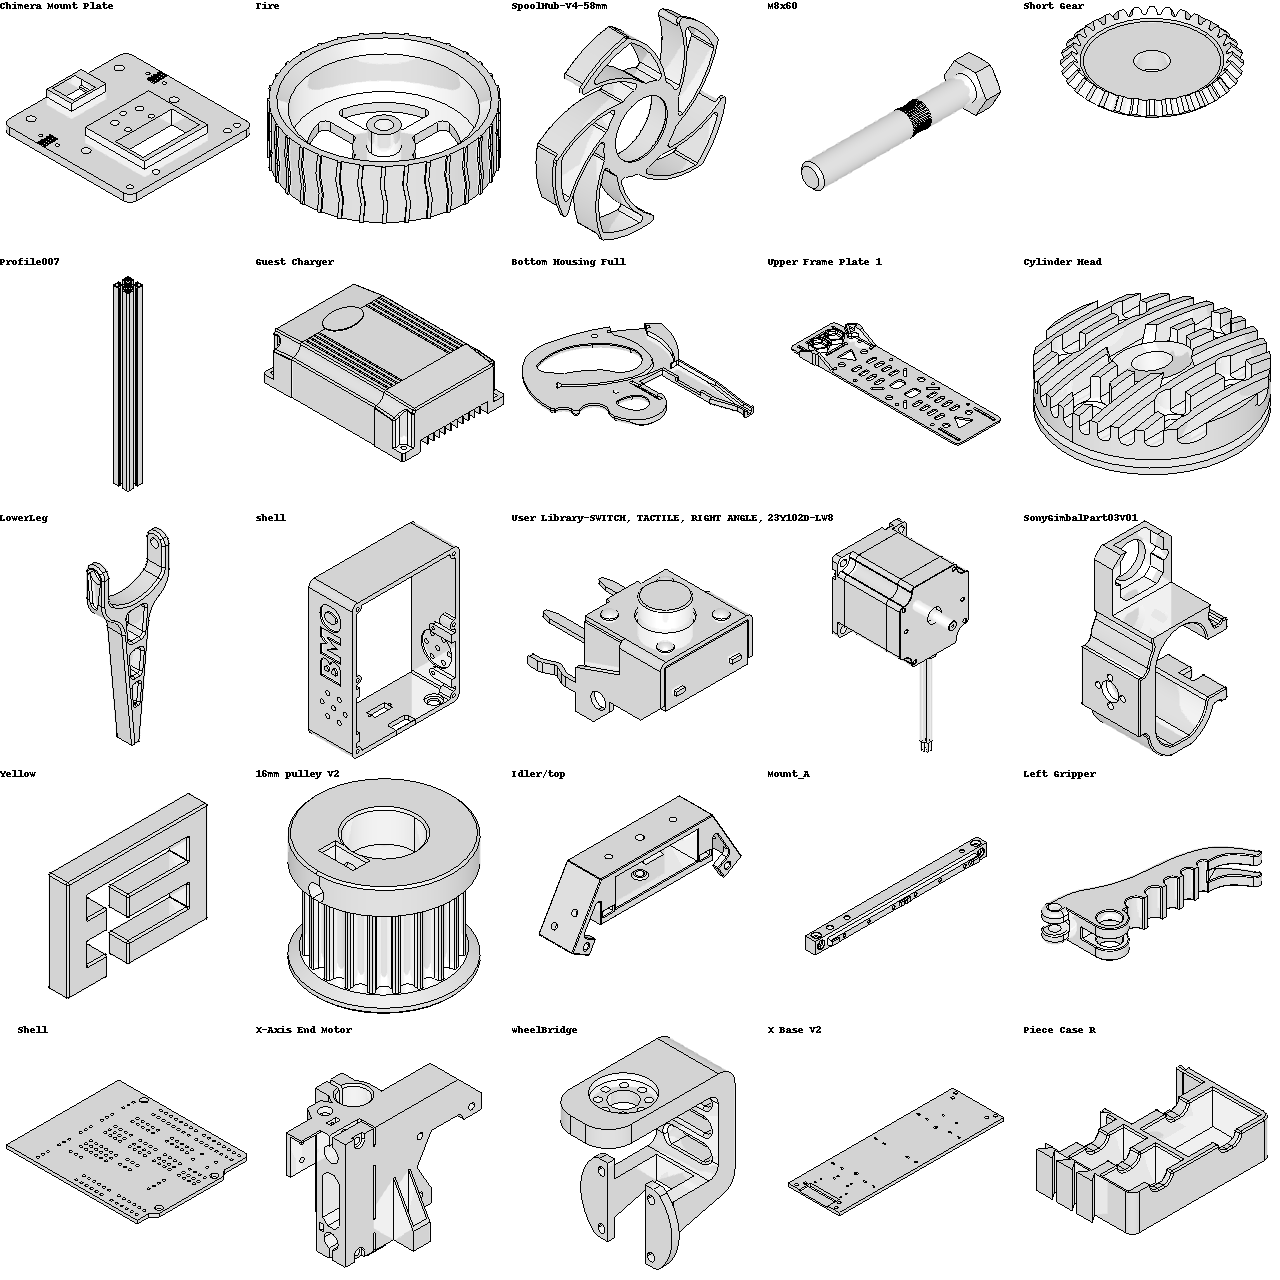

XL (300 < num_faces) prismatic bodies (can be approximated)

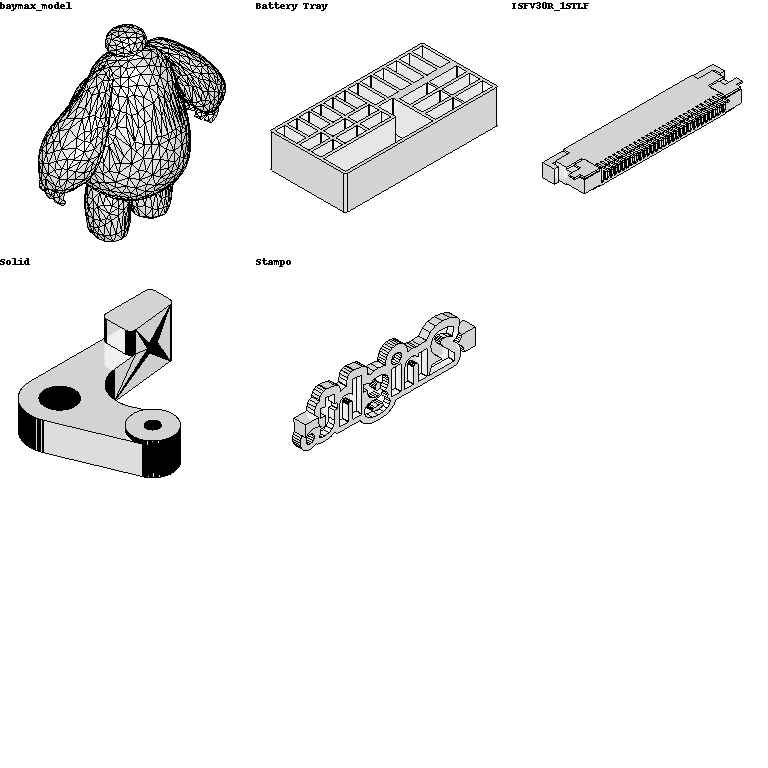

XL (300 < num_faces) non-prismatic bodies which can be approximated

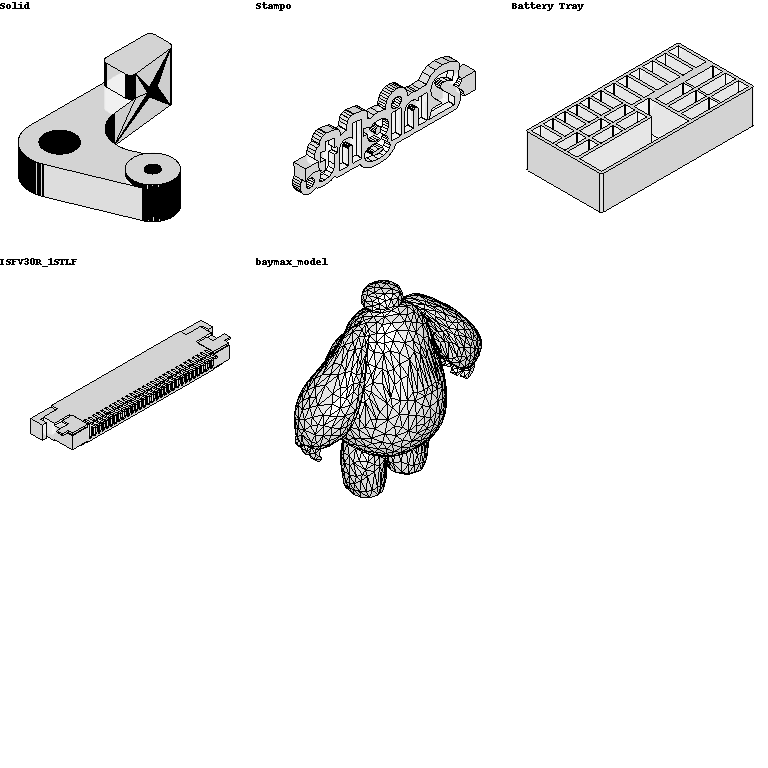

XL (300 < num_faces) non-prismatic bodies which can't be approximated

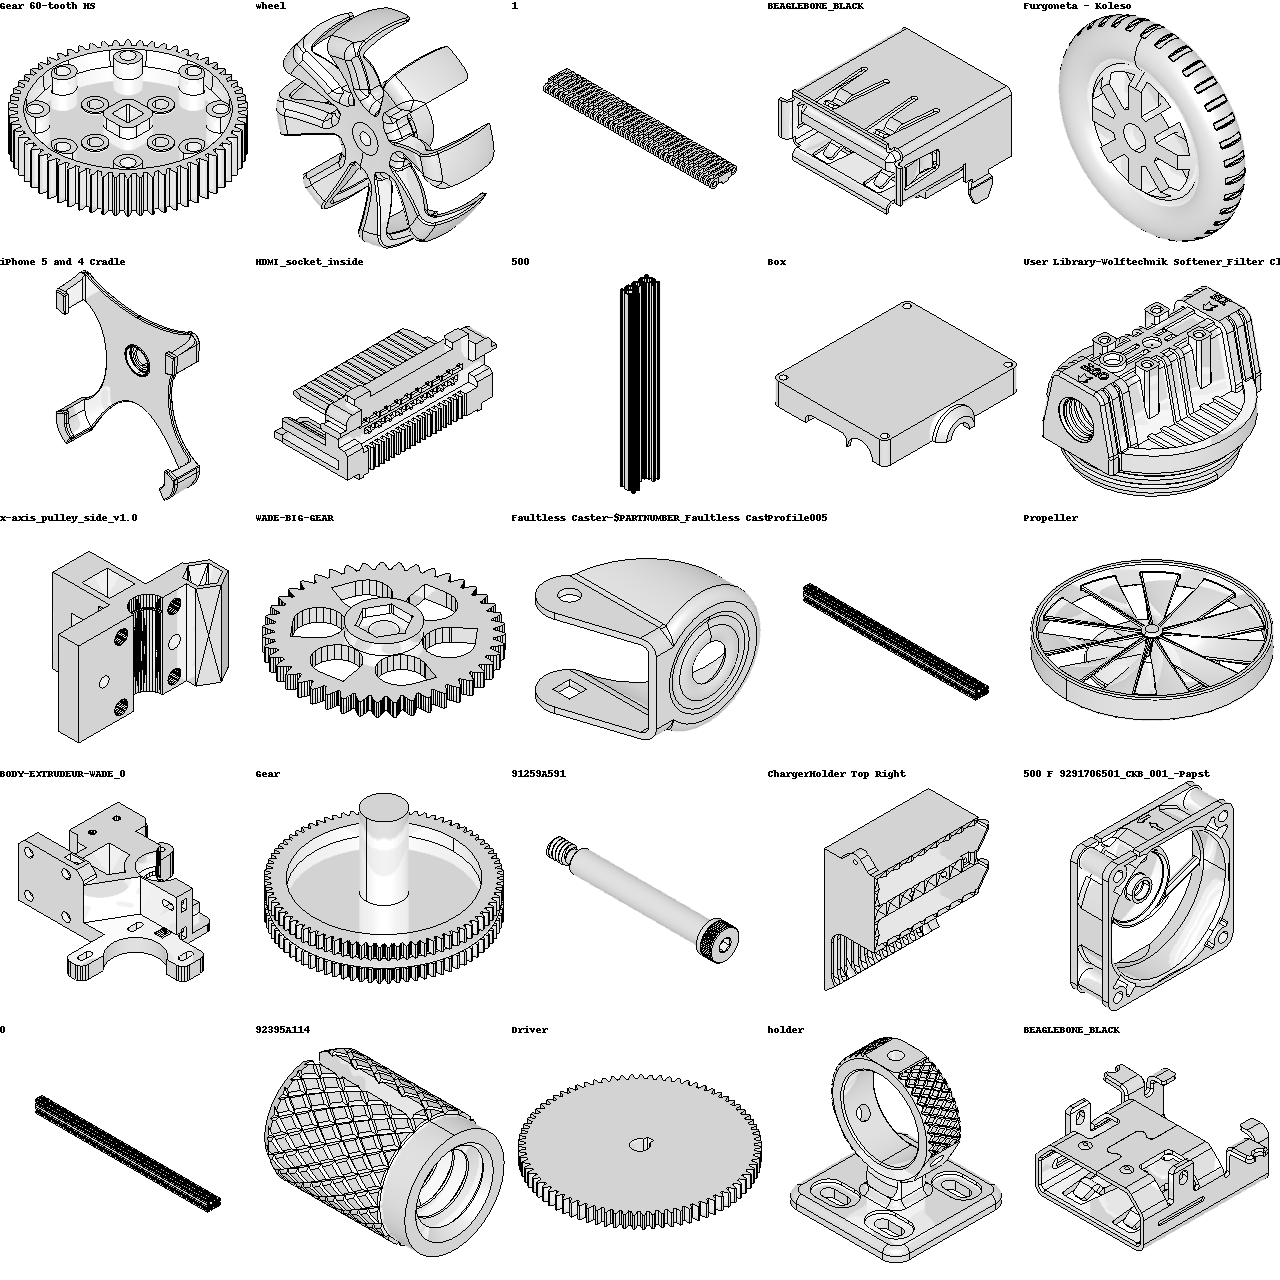

In [20]:
def display_image_grid(msg, face_bin, file_stem_dict):
    display(Markdown(msg))
    file_stems = file_stem_dict[face_bin]
    img =  create_image_grid_for_examples(file_stems, image_path)
    if img is not None:
        display(img)
    print(" ")
    print(" ")
    
face_bins = [
    "Very small (num_faces <= 6)",
    "Small (6 < num_faces <= 30)",
    "Medium (30 < num_faces <= 100)",
    "Large (100 < num_faces <= 300)",
    "XL (300 < num_faces)"
]
for face_bin in face_bins:
    display_image_grid(
        f"{face_bin} prismatic bodies (can be approximated)", 
        face_bin,
        prismatic_bodies_which_can_be_approximated
    )
    
    display_image_grid(
        f"{face_bin} non-prismatic bodies which can be approximated", 
        face_bin,
        prismatic_bodies_which_can_be_approximated
    )
    
    display_image_grid(
        f"{face_bin} non-prismatic bodies which can't be approximated", 
        face_bin,
        non_prismatic_bodies_which_cant_be_approximated
    )